# Parametric POD Reduced-Order Modeling via Amsallem--Farhat Grassmann Interpolation

This notebook develops a parametric reduced-order modeling framework for the two-dimensional diffusion equation using Proper Orthogonal Decomposition (POD) and the Amsallem--Farhat interpolation method on the Grassmann manifold.

Starting from a family of Full-Order Models (FOMs) parameterized by the diffusion coefficient, local POD subspaces are constructed at selected training parameters. These subspaces are then interpreted as points on a Grassmann manifold and interpolated at an unseen parameter through a tangent-space representation.

The resulting interpolated subspace is used to construct a POD--Galerkin Reduced-Order Model (ROM), which is finally compared with the corresponding Full-Order Model.

---

# 0. Imports

In [1]:
from dataclasses import dataclass
import time

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from numpy.typing import NDArray
from scipy import linalg
from scipy.interpolate import CubicSpline

from scipy import sparse
from scipy.sparse import linalg as sparse_linalg

from mpi4py import MPI
from petsc4py import PETSc

from dolfinx import fem, mesh
from dolfinx.fem import petsc

import ufl


plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

---

# 1. Problem Definition


## 1.1 Governing PDE


We consider the transient diffusion equation on the unit square $\Omega = (0,1)^2$, parameterized by the diffusion coefficient $\nu > 0$, with homogeneous Dirichlet boundary conditions:


$$
\begin{cases}
\dfrac{\partial u}{\partial t}-\nu\Delta u=0,
& \text{in } \Omega\times(0,T],\\[6pt]
u=0,
& \text{on } \partial\Omega\times(0,T],\\[6pt]
u(\mathbf{x},0)=u_0(\mathbf{x}),
& \text{in } \Omega.
\end{cases}
$$

For training parameters $\nu_1,\ldots,\nu_N$, a local POD subspace will be constructed for each $\nu_i$. These subspaces are then interpolated on the Grassmann manifold to approximate the reduced space associated with an unseen target parameter $\nu^\star$.

## 1.2 Numerical Configuration

The numerical configuration is kept unchanged from the non-parametric model:

- $T=0.5$, $N_t=200$, $\Delta t=T/N_t$;
- structured $30\times30$ triangular mesh;
- continuous $P_1$ finite elements.

Thus, all snapshot vectors belong to the same discrete space $\mathbb{R}^{n_h}$, allowing POD subspaces associated with different parameter values to be compared and interpolated.

In [2]:
@dataclass(frozen=True)
class NumericalConfig:
    """Numerical parameters shared by all Full-Order Model simulations."""

    final_time: float = 0.5
    num_time_steps: int = 200
    mesh_cells_x: int = 30
    mesh_cells_y: int = 30
    polynomial_degree: int = 1

    def __post_init__(self) -> None:
        """Validate the numerical configuration."""
        if self.final_time <= 0.0:
            raise ValueError("final_time must be strictly positive.")

        if self.num_time_steps <= 0:
            raise ValueError("num_time_steps must be strictly positive.")

        if self.mesh_cells_x <= 0 or self.mesh_cells_y <= 0:
            raise ValueError("Mesh dimensions must be strictly positive.")

        if self.polynomial_degree <= 0:
            raise ValueError("polynomial_degree must be strictly positive.")

    @property
    def time_step(self) -> float:
        """Return the uniform time-step size."""
        return self.final_time / self.num_time_steps


CONFIG = NumericalConfig()

BASELINE_DIFFUSIVITY = 1.0e-2

In [3]:
print(f"Final time             : {CONFIG.final_time}")
print(f"Number of time steps   : {CONFIG.num_time_steps}")
print(f"Time step              : {CONFIG.time_step:.2e}")
print(
    "Mesh resolution        : "
    f"{CONFIG.mesh_cells_x} x {CONFIG.mesh_cells_y}"
)
print(f"Finite element degree  : {CONFIG.polynomial_degree}")
print(f"Baseline diffusivity   : {BASELINE_DIFFUSIVITY:.2e}")

Final time             : 0.5
Number of time steps   : 200
Time step              : 2.50e-03
Mesh resolution        : 30 x 30
Finite element degree  : 1
Baseline diffusivity   : 1.00e-02


---

# 2. Finite Element Discretization

 Since the finite element discretization is independent of $\nu$, it is constructed once and reused for all parameter values.

## 2.1 Mesh and Finite Element Space

Let $V_h = \operatorname{span}\{\varphi_1,\ldots,\varphi_{n_h}\}
\subset H_0^1(\Omega)$ denote the finite element space. The unit square is discretized using a structured $30\times30$ triangular mesh, with continuous $P_1$ finite elements.

In [4]:
COMM = MPI.COMM_WORLD

if COMM.size != 1:
    raise RuntimeError(
        "This notebook currently requires serial execution because the "
        "POD and Grassmann operations use global dense NumPy arrays."
    )

domain = mesh.create_unit_square(
    COMM,
    CONFIG.mesh_cells_x,
    CONFIG.mesh_cells_y,
)

function_space = fem.functionspace(
    domain,
    ("CG", CONFIG.polynomial_degree),
)

num_dofs = function_space.dofmap.index_map.size_global

print(f"Number of finite element DOFs: {num_dofs}")

Number of finite element DOFs: 961


In [5]:
dof_coordinates = function_space.tabulate_dof_coordinates()[:, :2]

triangulation = mtri.Triangulation(
    dof_coordinates[:, 0],
    dof_coordinates[:, 1],
)

## 2.2 Boundary Conditions

Homogeneous Dirichlet boundary conditions are imposed on the entire boundary: $u_h = 0$ on $\partial\Omega$.

Because these boundary conditions do not depend on the diffusion coefficient, the associated boundary degrees of freedom are identified once and reused for all parameter values.

In [6]:
boundary_dimension = domain.topology.dim - 1

boundary_facets = mesh.locate_entities_boundary(
    domain,
    boundary_dimension,
    lambda coordinates: np.full(
        coordinates.shape[1],
        True,
        dtype=bool,
    ),
)

boundary_dofs = fem.locate_dofs_topological(
    function_space,
    boundary_dimension,
    boundary_facets,
)

homogeneous_dirichlet_bc = fem.dirichletbc(
    PETSc.ScalarType(0.0),
    boundary_dofs,
    function_space,
)

## 2.3 Initial Condition

The initial condition is chosen as the smooth multi-frequency field:

$$
\begin{aligned}
u_0(x,y)
={}&
\sin(\pi x)\sin(\pi y)
+\frac{1}{2}\sin(2\pi x)\sin(3\pi y)\\
&+\frac{1}{3}\sin(4\pi x)\sin(2\pi y)
+\frac{1}{4}\sin(3\pi x)\sin(5\pi y)\\
&+\frac{1}{5}\sin(6\pi x)\sin(4\pi y).
\end{aligned}
$$

Each term is an eigenfunction of the Laplace operator with homogeneous Dirichlet boundary conditions on the unit square. For a mode $\sin(k\pi x)\sin(\ell\pi y)$, the corresponding decay rate under the diffusion equation is proportional to :

$$
\nu\pi^2(k^2+\ell^2).
$$

The initial condition therefore excites several spatial scales with different decay rates. Varying $\nu$ modifies these temporal decay rates and consequently changes the snapshot ensemble and its associated POD subspace.

In [7]:
def initial_condition(coordinates: NDArray[np.float64]) -> NDArray[np.float64]:
    """Evaluate the smooth multi-frequency initial condition.

    Parameters
    ----------
    coordinates
        Spatial coordinates with shape ``(geometric_dimension, num_points)``.

    Returns
    -------
    NDArray[np.float64]
        Initial-condition values evaluated at the supplied coordinates.
    """
    x_coordinate = coordinates[0]
    y_coordinate = coordinates[1]

    return (
        np.sin(np.pi * x_coordinate) * np.sin(np.pi * y_coordinate)
        + 0.5
        * np.sin(2.0 * np.pi * x_coordinate)
        * np.sin(3.0 * np.pi * y_coordinate)
        + (1.0 / 3.0)
        * np.sin(4.0 * np.pi * x_coordinate)
        * np.sin(2.0 * np.pi * y_coordinate)
        + 0.25
        * np.sin(3.0 * np.pi * x_coordinate)
        * np.sin(5.0 * np.pi * y_coordinate)
        + 0.20
        * np.sin(6.0 * np.pi * x_coordinate)
        * np.sin(4.0 * np.pi * y_coordinate)
    )

## 2.4 Mass and Stiffness Matrices

The mass and stiffness matrices are defined by

$$
M_{ij}=\int_\Omega \varphi_j\varphi_i\,dx,
\qquad
K_{ij}=\int_\Omega \nabla\varphi_j\cdot\nabla\varphi_i\,dx.
$$

For coefficient vectors $\mathbf{u},\mathbf{v}\in\mathbb{R}^{n_h}$, the mass matrix represents the finite element $L^2(\Omega)$ inner product:
$$

\langle u_h,v_h\rangle_{L^2(\Omega)}
=
\mathbf{u}^T M \mathbf{v}.
$$

Both matrices are independent of $\nu$. Under backward Euler time integration, the FOM system matrix is:

$$
A(\nu)=M+\Delta t\,\nu K.
$$

The mass matrix also defines the inner product used to construct the POD bases and, later, the transformation from the mass-weighted finite element geometry to the Euclidean Grassmann geometry.

In [8]:
trial_function = ufl.TrialFunction(function_space)
test_function = ufl.TestFunction(function_space)

mass_form = ufl.inner(
    trial_function,
    test_function,
) * ufl.dx

stiffness_form = ufl.inner(
    ufl.grad(trial_function),
    ufl.grad(test_function),
) * ufl.dx

mass_matrix = fem.petsc.assemble_matrix(
    fem.form(mass_form)
)
mass_matrix.assemble()

stiffness_matrix = fem.petsc.assemble_matrix(
    fem.form(stiffness_form)
)
stiffness_matrix.assemble()


dof_indices = np.arange(num_dofs, dtype=np.int32)

mass_matrix_np = mass_matrix.getValues(
    dof_indices,
    dof_indices,
)

stiffness_matrix_np = stiffness_matrix.getValues(
    dof_indices,
    dof_indices,
)


SYMMETRY_TOLERANCE = 1.0e-12

if not np.allclose(
    mass_matrix_np,
    mass_matrix_np.T,
    atol=SYMMETRY_TOLERANCE,
    rtol=0.0,
):
    raise RuntimeError("The assembled mass matrix is not numerically symmetric.")

if not np.allclose(
    stiffness_matrix_np,
    stiffness_matrix_np.T,
    atol=SYMMETRY_TOLERANCE,
    rtol=0.0,
):
    raise RuntimeError(
        "The assembled stiffness matrix is not numerically symmetric."
    )

print(f"Mass matrix shape      : {mass_matrix_np.shape}")
print(f"Stiffness matrix shape : {stiffness_matrix_np.shape}")

Mass matrix shape      : (961, 961)
Stiffness matrix shape : (961, 961)


---

# 3. Parameterized Full-Order Model

Using the backward Euler scheme, the semi-discrete finite element problem at time $t_{n+1}$ reads:

$$
\left(
\frac{u_h^{n+1}-u_h^n}{\Delta t},
v_h
\right)_{L^2(\Omega)}
+
\nu
\left(
\nabla u_h^{n+1},
\nabla v_h
\right)_{L^2(\Omega)}
=0,
\qquad \forall v_h\in V_h.
$$

In matrix form,

$$
A(\nu)\mathbf{u}^{n+1}
=
M\mathbf{u}^{n},
\qquad
A(\nu)=M+\Delta t\,\nu K.
$$

For a fixed $\nu$, $A(\nu)$ is factorized once and reused at every time step. The time integration is performed on the interior degrees of freedom, with zero values imposed on the boundary.

In [9]:
def petsc_matrix_to_csr(matrix: PETSc.Mat) -> sparse.csr_matrix:
    """Convert a sequential PETSc matrix to SciPy CSR format.

    Parameters
    ----------
    matrix
        Sequential PETSc matrix.

    Returns
    -------
    scipy.sparse.csr_matrix
        Sparse matrix with the same entries as the PETSc matrix.

    Raises
    ------
    RuntimeError
        If the notebook is executed with more than one MPI process.
    """
    if COMM.size != 1:
        raise RuntimeError(
            "PETSc-to-SciPy conversion requires serial execution."
        )

    row_pointers, column_indices, values = matrix.getValuesCSR()

    return sparse.csr_matrix(
        (values, column_indices, row_pointers),
        shape=matrix.getSize(),
    )


mass_matrix_csr = petsc_matrix_to_csr(mass_matrix)
stiffness_matrix_csr = petsc_matrix_to_csr(stiffness_matrix)

all_dofs = np.arange(num_dofs, dtype=np.int32)

interior_dofs = np.setdiff1d(
    all_dofs,
    boundary_dofs,
    assume_unique=False,
)

mass_matrix_interior = mass_matrix_csr[
    interior_dofs, :
][:, interior_dofs].tocsc()

stiffness_matrix_interior = stiffness_matrix_csr[
    interior_dofs, :
][:, interior_dofs].tocsc()

print(f"Total DOFs    : {num_dofs}")
print(f"Boundary DOFs : {len(boundary_dofs)}")
print(f"Interior DOFs : {len(interior_dofs)}")

Total DOFs    : 961
Boundary DOFs : 120
Interior DOFs : 841


## 3.1 Full-Order Model Result

Each FOM simulation returns the snapshot trajectory, parameter value, time grid, and computational cost.

These quantities are stored in a dedicated result container, making each simulation self-contained and easier to reuse throughout the parametric study.


In [10]:
@dataclass(frozen=True)
class FOMResult:
    """Container for a parameterized Full-Order Model simulation."""

    diffusivity: float
    time_grid: NDArray[np.float64]
    snapshots: NDArray[np.float64]
    wall_time_seconds: float

    @property
    def num_snapshots(self) -> int:
        """Return the number of stored temporal snapshots."""
        return self.snapshots.shape[1]

    @property
    def final_state(self) -> NDArray[np.float64]:
        """Return the final Full-Order Model state."""
        return self.snapshots[:, -1]

## 3.2 Parameterized Solver

The function below solves the Full-Order Model for an arbitrary diffusion coefficient $\nu>0$.

For each parameter value:

1. the parameter-dependent system matrix is assembled;
2. a sparse LU factorization is computed once;
3. backward Euler time stepping is performed;
4. the solution at every time level, including the initial condition, is stored.

The resulting snapshot matrix is

$$
S(\nu)
=
\begin{bmatrix}
| & | & & | \\
\mathbf{u}^0(\nu)
&
\mathbf{u}^1(\nu)
&
\cdots
&
\mathbf{u}^{N_t}(\nu) \\
| & | & & |
\end{bmatrix}
\in
\mathbb{R}^{n_h\times(N_t+1)}.
$$

Preallocating this matrix avoids repeated memory reallocations during time integration.

In [11]:
def solve_full_order_model(diffusivity: float) -> FOMResult:
    """Solve the parameterized diffusion Full-Order Model.

    The diffusion equation is discretized in time using backward Euler and
    in space using the previously constructed finite element space. Because
    the system matrix is constant for a fixed diffusivity, a sparse LU
    factorization is computed once and reused throughout the time integration.

    Parameters
    ----------
    diffusivity
        Strictly positive diffusion coefficient.

    Returns
    -------
    FOMResult
        Parameter value, temporal grid, snapshot matrix, and measured
        wall-clock time.

    Raises
    ------
    ValueError
        If the diffusion coefficient is not finite and strictly positive.
    """
    if not np.isfinite(diffusivity) or diffusivity <= 0.0:
        raise ValueError(
            "diffusivity must be finite and strictly positive."
        )

    time_grid = np.linspace(
        0.0,
        CONFIG.final_time,
        CONFIG.num_time_steps + 1,
        dtype=np.float64,
    )

    initial_function = fem.Function(function_space)
    initial_function.interpolate(initial_condition)
    initial_function.x.scatter_forward()

    initial_state = initial_function.x.array.copy()
    initial_state[boundary_dofs] = 0.0

    snapshots = np.empty(
        (num_dofs, CONFIG.num_time_steps + 1),
        dtype=np.float64,
    )
    snapshots[:, 0] = initial_state

    interior_state = initial_state[interior_dofs].copy()

    start_time = time.perf_counter()

    system_matrix = (
        mass_matrix_interior
        + CONFIG.time_step
        * diffusivity
        * stiffness_matrix_interior
    ).tocsc()

    linear_solver = sparse_linalg.splu(system_matrix)

    for time_index in range(1, CONFIG.num_time_steps + 1):
        right_hand_side = mass_matrix_interior @ interior_state

        interior_state = linear_solver.solve(right_hand_side)

        snapshots[:, time_index] = 0.0
        snapshots[interior_dofs, time_index] = interior_state

    wall_time_seconds = time.perf_counter() - start_time

    return FOMResult(
        diffusivity=float(diffusivity),
        time_grid=time_grid,
        snapshots=snapshots,
        wall_time_seconds=wall_time_seconds,
    )

## 3.3 Baseline Simulation

The parameterized solver is first evaluated at the reference diffusion coefficient $\nu_0 = 10^{-2}$, corresponding to the value used in the original non-parametric model.

This baseline simulation is used to compare the numerical solution with the analytical solution and verify the accuracy of the FOM solver.

In [12]:
baseline_result = solve_full_order_model(
    diffusivity=BASELINE_DIFFUSIVITY
)

print(
    f"Diffusivity         : {baseline_result.diffusivity:.2e}"
)
print(
    f"Snapshot matrix     : {baseline_result.snapshots.shape}"
)
print(
    f"Number of snapshots : {baseline_result.num_snapshots}"
)
print(
    f"FOM wall time       : "
    f"{baseline_result.wall_time_seconds:.3f} s"
)

Diffusivity         : 1.00e-02
Snapshot matrix     : (961, 201)
Number of snapshots : 201
FOM wall time       : 0.036 s


## 3.4 Analytical Reference Solution

The selected initial condition is a finite linear combination of Laplacian eigenfunctions. Consequently, the diffusion problem admits an explicit analytical solution.

For $\phi_{k,\ell}(x,y) = \sin(k\pi x)\sin(\ell\pi y)$, we have:

$$
-\Delta \phi_{k,\ell}
=
\pi^2(k^2+\ell^2)\phi_{k,\ell}.
$$

The corresponding diffusion mode therefore evolves as:

$$
\phi_{k,\ell}(x,y,t)
=
e^{-\nu\pi^2(k^2+\ell^2)t}
\phi_{k,\ell}(x,y,0).
$$

The analytical solution provides an independent reference against which the finite element and backward Euler discretizations can be validated.

In [13]:
def exact_solution(
    coordinates: NDArray[np.float64],
    time_value: float,
    diffusivity: float,
) -> NDArray[np.float64]:
    """Evaluate the analytical solution of the diffusion problem.

    Parameters
    ----------
    coordinates
        Spatial coordinates with shape ``(2, num_points)``.
    time_value
        Evaluation time.
    diffusivity
        Strictly positive diffusion coefficient.

    Returns
    -------
    NDArray[np.float64]
        Analytical solution evaluated at the supplied coordinates.
    """
    if time_value < 0.0:
        raise ValueError("time_value must be non-negative.")

    if not np.isfinite(diffusivity) or diffusivity <= 0.0:
        raise ValueError(
            "diffusivity must be finite and strictly positive."
        )

    x_coordinate = coordinates[0]
    y_coordinate = coordinates[1]

    modes = (
        (1, 1, 1.0),
        (2, 3, 1.0 / 2.0),
        (4, 2, 1.0 / 3.0),
        (3, 5, 1.0 / 4.0),
        (6, 4, 1.0 / 5.0),
    )

    solution = np.zeros_like(x_coordinate, dtype=np.float64)

    for x_wave_number, y_wave_number, amplitude in modes:
        eigenvalue = np.pi**2 * (
            x_wave_number**2 + y_wave_number**2
        )

        temporal_decay = np.exp(
            -diffusivity * eigenvalue * time_value
        )

        solution += (
            amplitude
            * temporal_decay
            * np.sin(x_wave_number * np.pi * x_coordinate)
            * np.sin(y_wave_number * np.pi * y_coordinate)
        )

    return solution

In [14]:
def mass_weighted_norm(
    vector: NDArray[np.float64],
    mass_matrix: NDArray[np.float64],
) -> float:
    """Compute the norm induced by the finite element mass matrix."""
    squared_norm = float(vector @ mass_matrix @ vector)

    return float(np.sqrt(max(squared_norm, 0.0)))


def relative_mass_weighted_error(
    reference: NDArray[np.float64],
    approximation: NDArray[np.float64],
    mass_matrix: NDArray[np.float64],
) -> float:
    """Compute the relative error induced by the FEM mass matrix."""
    reference_norm = mass_weighted_norm(
        reference,
        mass_matrix,
    )

    if reference_norm <= np.finfo(np.float64).eps:
        raise ValueError(
            "Cannot compute a relative error for a near-zero reference."
        )

    error = reference - approximation

    return (
        mass_weighted_norm(error, mass_matrix)
        / reference_norm
    )

In [15]:
baseline_exact_errors = np.empty(
    baseline_result.num_snapshots,
    dtype=np.float64,
)

evaluation_coordinates = dof_coordinates.T

for time_index, time_value in enumerate(
    baseline_result.time_grid
):
    analytical_state = exact_solution(
        coordinates=evaluation_coordinates,
        time_value=float(time_value),
        diffusivity=baseline_result.diffusivity,
    )

    baseline_exact_errors[time_index] = (
        relative_mass_weighted_error(
            reference=analytical_state,
            approximation=baseline_result.snapshots[:, time_index],
            mass_matrix=mass_matrix_np,
        )
    )

print(
    f"Mean FOM error    : "
    f"{np.mean(baseline_exact_errors):.3e}"
)
print(
    f"Maximum FOM error : "
    f"{np.max(baseline_exact_errors):.3e}"
)
print(
    f"Final-time error  : "
    f"{baseline_exact_errors[-1]:.3e}"
)

Mean FOM error    : 5.921e-03
Maximum FOM error : 7.118e-03
Final-time error  : 6.501e-03


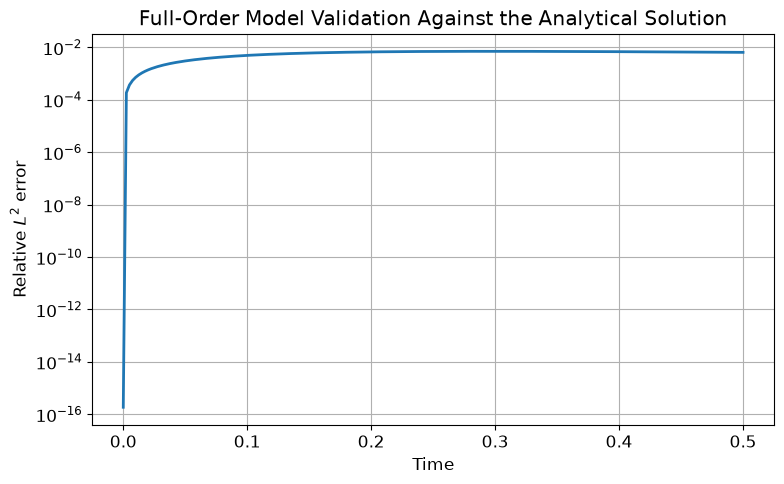

In [16]:
fig, axis = plt.subplots()

axis.semilogy(
    baseline_result.time_grid,
    baseline_exact_errors,
    linewidth=2.0,
)

axis.set_xlabel("Time")
axis.set_ylabel("Relative $L^2$ error")
axis.set_title("Full-Order Model Validation Against the Analytical Solution")
axis.grid(True)

fig.tight_layout()
plt.show()

---

# 4. Parametric Training Dataset

The Grassmann interpolation requires POD subspaces computed at a finite set of training parameters. POD subspaces are computed at 7 uniformly spaced training parameters over:

$$
\nu \in \left[5\times10^{-3},\,2\times10^{-2}\right].
$$

This range includes the baseline diffusivity $\nu=10^{-2}$ and yields distinct POD subspaces.

The validation points are not chosen at the interval midpoints, since this would make the two neighboring training parameters equally close and therefore prevent the selection of a unique reference point for the Amsallem--Farhat interpolation.

In [17]:
DIFFUSIVITY_MIN = 5.0e-3
DIFFUSIVITY_MAX = 2.0e-2
NUM_TRAINING_PARAMETERS = 7

training_diffusivities = np.linspace(
    DIFFUSIVITY_MIN,
    DIFFUSIVITY_MAX,
    NUM_TRAINING_PARAMETERS,
    dtype=np.float64,
)

VALIDATION_OFFSET_FRACTION = 0.4

parameter_intervals = np.diff(training_diffusivities)

validation_diffusivities = (
    training_diffusivities[:-1]
    + VALIDATION_OFFSET_FRACTION * parameter_intervals
)

PRIMARY_TARGET_INDEX = 3

PRIMARY_TARGET_DIFFUSIVITY = float(
    validation_diffusivities[PRIMARY_TARGET_INDEX]
)

print("Training diffusivities:")
print(training_diffusivities)

print("\nValidation diffusivities:")
print(validation_diffusivities)

print(
    "\nPrimary target diffusivity: "
    f"{PRIMARY_TARGET_DIFFUSIVITY:.5f}"
)

Training diffusivities:
[0.005  0.0075 0.01   0.0125 0.015  0.0175 0.02  ]

Validation diffusivities:
[0.006  0.0085 0.011  0.0135 0.016  0.0185]

Primary target diffusivity: 0.01350


In [18]:
if not np.all(np.isfinite(training_diffusivities)):
    raise ValueError("Training diffusivities must be finite.")

if np.any(training_diffusivities <= 0.0):
    raise ValueError("Training diffusivities must be strictly positive.")

if not np.all(np.diff(training_diffusivities) > 0.0):
    raise ValueError(
        "Training diffusivities must be strictly increasing."
    )

if np.any(
    np.isclose(
        validation_diffusivities[:, None],
        training_diffusivities[None, :],
    )
):
    raise RuntimeError(
        "Validation parameters must not coincide with training parameters."
    )

if not (
    training_diffusivities[0]
    < PRIMARY_TARGET_DIFFUSIVITY
    < training_diffusivities[-1]
):
    raise RuntimeError(
        "The primary target must lie inside the training interval."
    )

## 4.1 Offline Snapshot Generation

A FOM trajectory is computed for each training parameter $\nu_i$, yielding the offline dataset

$$
\mathcal{D}_{\mathrm{train}}
=
\left\{
S(\nu_i)
\right\}_{i=1}^{N},
\qquad
S(\nu_i)\in\mathbb{R}^{n_h\times(N_t+1)}.
$$

Only these training trajectories are used to construct the local POD subspaces; validation trajectories are excluded from the offline stage.

In [19]:
def generate_training_dataset(
    diffusivities: NDArray[np.float64],
) -> list[FOMResult]:
    """Generate Full-Order Model trajectories at training parameters.

    Parameters
    ----------
    diffusivities
        One-dimensional array of strictly increasing positive diffusion
        coefficients.

    Returns
    -------
    list[FOMResult]
        Full-Order Model results ordered consistently with ``diffusivities``.

    Raises
    ------
    ValueError
        If the parameter array is invalid.
    """
    diffusivities = np.asarray(diffusivities, dtype=np.float64)

    if diffusivities.ndim != 1 or diffusivities.size == 0:
        raise ValueError(
            "diffusivities must be a non-empty one-dimensional array."
        )

    if not np.all(np.isfinite(diffusivities)):
        raise ValueError("All diffusivities must be finite.")

    if np.any(diffusivities <= 0.0):
        raise ValueError(
            "All diffusivities must be strictly positive."
        )

    if np.any(np.diff(diffusivities) <= 0.0):
        raise ValueError(
            "diffusivities must be strictly increasing."
        )

    results: list[FOMResult] = []

    for parameter_index, diffusivity in enumerate(
        diffusivities,
        start=1,
    ):
        print(
            f"[{parameter_index:02d}/{diffusivities.size:02d}] "
            f"Solving FOM for nu = {diffusivity:.5f}"
        )

        result = solve_full_order_model(
            diffusivity=float(diffusivity)
        )
        results.append(result)

    return results


training_results = generate_training_dataset(
    training_diffusivities
)

[01/07] Solving FOM for nu = 0.00500
[02/07] Solving FOM for nu = 0.00750
[03/07] Solving FOM for nu = 0.01000
[04/07] Solving FOM for nu = 0.01250
[05/07] Solving FOM for nu = 0.01500
[06/07] Solving FOM for nu = 0.01750
[07/07] Solving FOM for nu = 0.02000


In [20]:
offline_wall_time = sum(
    result.wall_time_seconds
    for result in training_results
)

print(
    f"Number of training simulations : {len(training_results)}"
)
print(
    f"Snapshots per simulation       : "
    f"{training_results[0].num_snapshots}"
)
print(
    f"Total offline FOM wall time    : "
    f"{offline_wall_time:.3f} s"
)

Number of training simulations : 7
Snapshots per simulation       : 201
Total offline FOM wall time    : 0.151 s


## 4.2 Influence of the Diffusion Parameter

Before constructing reduced spaces, the effect of $\nu$ on the FOM dynamics is examined.

For each training trajectory, we monitor the finite element $L^2(\Omega)$ norm

$$
\|u_h(t;\nu)\|_{L^2(\Omega)}
=
\sqrt{
\mathbf{u}(t;\nu)^T
M
\mathbf{u}(t;\nu)
}.
$$

Larger values of $\nu$ produce faster dissipation, especially for high-frequency components of the initial condition. This changes the relative contribution of the spatial modes over time and therefore the snapshot ensemble used to construct the POD basis.

In [21]:
def compute_snapshot_norms(
    snapshots: NDArray[np.float64],
    mass_matrix: sparse.spmatrix,
) -> NDArray[np.float64]:
    """Compute mass-weighted norms of all snapshot columns.

    Parameters
    ----------
    snapshots
        Snapshot matrix with shape ``(num_dofs, num_snapshots)``.
    mass_matrix
        Finite element mass matrix.

    Returns
    -------
    NDArray[np.float64]
        Mass-weighted norm of each snapshot.
    """
    if snapshots.ndim != 2:
        raise ValueError("snapshots must be a two-dimensional array.")

    if mass_matrix.shape != (
        snapshots.shape[0],
        snapshots.shape[0],
    ):
        raise ValueError(
            "The mass matrix and snapshot dimensions are inconsistent."
        )

    mass_weighted_snapshots = mass_matrix @ snapshots

    squared_norms = np.einsum(
        "ij,ij->j",
        snapshots,
        mass_weighted_snapshots,
        optimize=True,
    )

    squared_norms = np.maximum(squared_norms, 0.0)

    return np.sqrt(squared_norms)

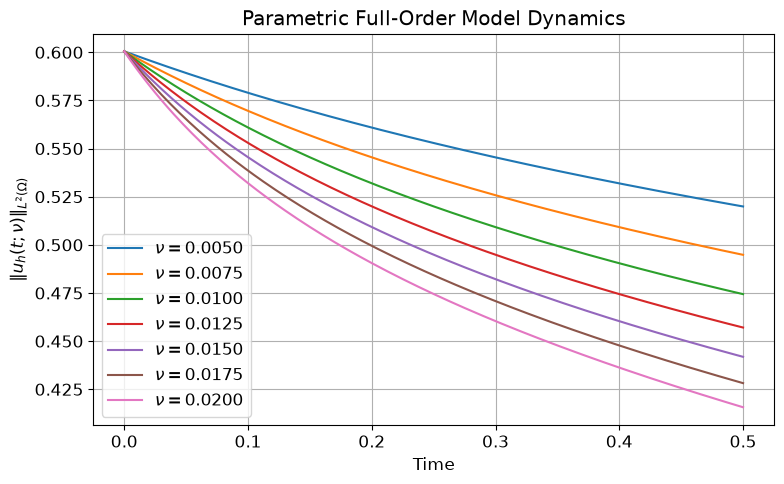

In [22]:
fig, axis = plt.subplots()

for result in training_results:
    trajectory_norms = compute_snapshot_norms(
        snapshots=result.snapshots,
        mass_matrix=mass_matrix_csr,
    )

    axis.plot(
        result.time_grid,
        trajectory_norms,
        label=fr"$\nu={result.diffusivity:.4f}$",
    )

axis.set_xlabel("Time")
axis.set_ylabel(r"$\|u_h(t;\nu)\|_{L^2(\Omega)}$")
axis.set_title("Parametric Full-Order Model Dynamics")
axis.legend()
axis.grid(True)

fig.tight_layout()
plt.show()

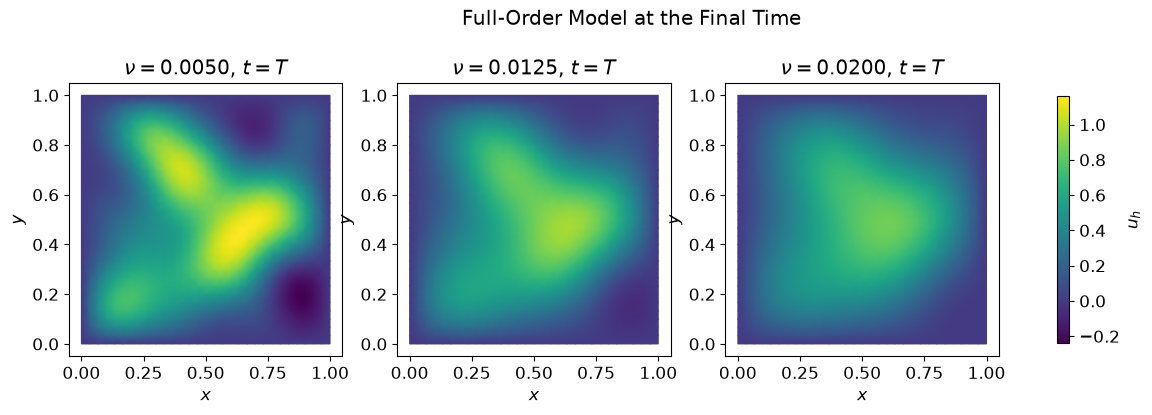

In [23]:
selected_indices = [
    0,
    len(training_results) // 2,
    len(training_results) - 1,
]

selected_results = [
    training_results[index]
    for index in selected_indices
]

global_minimum = min(
    result.final_state.min()
    for result in selected_results
)

global_maximum = max(
    result.final_state.max()
    for result in selected_results
)

fig, axes = plt.subplots(
    1,
    len(selected_results),
    figsize=(15, 4),
)

for axis, result in zip(
    axes,
    selected_results,
    strict=True,
):
    field = axis.tripcolor(
        triangulation,
        result.final_state,
        shading="gouraud",
        vmin=global_minimum,
        vmax=global_maximum,
    )

    axis.set_title(
        fr"$\nu={result.diffusivity:.4f}$, $t=T$"
    )
    axis.set_xlabel("$x$")
    axis.set_ylabel("$y$")
    axis.set_aspect("equal")

fig.colorbar(
    field,
    ax=axes,
    shrink=0.8,
    label="$u_h$",
)

fig.suptitle(
    "Full-Order Model at the Final Time",
    y=1.02,
)

plt.show()

---

# 5. Local POD Bases

For each training diffusivity $\nu_i$, a local POD basis is constructed from the corresponding snapshot matrix $S_i = S(\nu_i)$.

Because the snapshots originate from a finite element discretization, the POD is defined with respect to the discrete $L^2(\Omega)$ inner product induced by the mass matrix,

$$
\langle \mathbf{u},\mathbf{v}\rangle_M
=
\mathbf{u}^{T}M\mathbf{v}.
$$

Using the method of snapshots, the correlation matrix associated with the
parameter $\nu_i$ is:

$$
C_i
=
\frac{1}{N_s}
S_i^T M S_i.
$$

Let $\lambda_1^{(i)}
\geq
\lambda_2^{(i)}
\geq
\cdots
\geq 0$ denote its eigenvalues and $v_1^{(i)},v_2^{(i)},\ldots
$ the corresponding Euclidean-orthonormal eigenvectors. The POD modes are then:

$$
\phi_k^{(i)}
=
\frac{
S_i v_k^{(i)}
}{
\sqrt{N_s\lambda_k^{(i)}}
}.
$$

They satisfy $\left(\Phi_i\right)^T M \Phi_i = I$.

A separate POD decomposition is first computed at every training parameter.
A common reduced dimension will then be selected so that all reduced spaces
belong to the same Grassmann manifold.

In [24]:
@dataclass(frozen=True)
class PODResult:
    """Mass-weighted POD decomposition at a single parameter value."""

    diffusivity: float
    basis: NDArray[np.float64]
    eigenvalues: NDArray[np.float64]
    cumulative_energy: NDArray[np.float64]
    orthonormality_error: float

    @property
    def numerical_rank(self) -> int:
        """Return the number of numerically significant POD modes."""
        return self.eigenvalues.size

    def dimension_for_energy(self, threshold: float) -> int:
        """Return the smallest POD dimension reaching an energy threshold.

        Parameters
        ----------
        threshold
            Required cumulative energy ratio in the interval ``(0, 1]``.

        Returns
        -------
        int
            Smallest number of modes whose cumulative energy is at least
            ``threshold``.

        Raises
        ------
        ValueError
            If the threshold does not belong to ``(0, 1]``.
        """
        if not np.isfinite(threshold) or not 0.0 < threshold <= 1.0:
            raise ValueError(
                "The energy threshold must belong to the interval (0, 1]."
            )

        return int(
            np.searchsorted(
                self.cumulative_energy,
                threshold,
                side="left",
            )
            + 1
        )

## 5.1 Mass-Weighted POD Computation

The mass matrix is factorized once using a Cholesky decomposition, $M = R^T R$. For each snapshot matrix $S_i$, the mass-weighted snapshots are defined as:

$$
Y_i
=
\frac{R S_i}{\sqrt{N_s}}.
$$

The POD is then computed from the singular value decomposition:

$$
Y_i
=
U_i \Sigma_i V_i^T.
$$

This avoids explicitly forming the correlation matrix $S_i^T M S_i$, whose conditioning is less favorable.

Numerically significant modes are selected using a tolerance proportional to machine precision and to the largest singular value. The corresponding POD basis is recovered as:

$$
\Phi_i
=
R^{-1} U_i.
$$

By construction, the basis is $M$-orthonormal, $\Phi_i^T M \Phi_i = I$, which is checked numerically after the computation.

In [25]:
mass_cholesky_factor = linalg.cholesky(
    mass_matrix_np,
    lower=False,
    check_finite=False,
)

cholesky_reconstruction_error = (
    linalg.norm(
        mass_matrix_np
        - mass_cholesky_factor.T @ mass_cholesky_factor,
        ord="fro",
    )
    / linalg.norm(mass_matrix_np, ord="fro")
)

print(
    "Relative Cholesky reconstruction error: "
    f"{cholesky_reconstruction_error:.3e}"
)

Relative Cholesky reconstruction error: 1.197e-16


In [26]:
POD_ORTHONORMALITY_TOLERANCE = 1.0e-10


def compute_mass_weighted_pod(
    fom_result: FOMResult,
    mass_cholesky_factor: NDArray[np.float64],
) -> PODResult:
    """Compute a mass-weighted POD using a numerically stable SVD.

    The finite element mass matrix is assumed to admit the factorization

    ``M = R.T @ R``.

    The POD is obtained from the singular value decomposition of the
    mass-weighted snapshot matrix

    ``Y = R @ S / sqrt(num_snapshots)``.

    This formulation is mathematically equivalent to the method of snapshots
    but avoids explicitly forming the correlation matrix ``Y.T @ Y``, whose
    condition number is the square of that of ``Y``.

    Parameters
    ----------
    fom_result
        Full-Order Model trajectory from which the POD basis is constructed.
    mass_cholesky_factor
        Upper-triangular Cholesky factor ``R`` satisfying
        ``M = R.T @ R``.

    Returns
    -------
    PODResult
        POD basis, POD eigenvalues, cumulative energy distribution, and
        mass-orthonormality error.

    Raises
    ------
    ValueError
        If matrix dimensions are inconsistent.
    RuntimeError
        If the snapshot ensemble has zero numerical energy or the resulting
        POD basis fails the mass-orthonormality check.
    """
    snapshots = np.asarray(
        fom_result.snapshots,
        dtype=np.float64,
    )

    if snapshots.ndim != 2:
        raise ValueError(
            "The snapshot matrix must be two-dimensional."
        )

    num_dofs_local, num_snapshots = snapshots.shape

    if mass_cholesky_factor.shape != (
        num_dofs_local,
        num_dofs_local,
    ):
        raise ValueError(
            "The Cholesky factor dimensions are inconsistent "
            "with the snapshot matrix."
        )

    weighted_snapshots = (
        mass_cholesky_factor @ snapshots
    ) / np.sqrt(num_snapshots)

    left_singular_vectors, singular_values, _ = linalg.svd(
        weighted_snapshots,
        full_matrices=False,
        check_finite=False,
        lapack_driver="gesdd",
    )

    if (
        singular_values.size == 0
        or singular_values[0] <= np.finfo(np.float64).tiny
    ):
        raise RuntimeError(
            "The snapshot ensemble has zero numerical energy."
        )

    numerical_rank_tolerance = (
        max(weighted_snapshots.shape)
        * np.finfo(np.float64).eps
        * singular_values[0]
    )

    significant_modes = (
        singular_values > numerical_rank_tolerance
    )

    singular_values = singular_values[significant_modes]

    left_singular_vectors = left_singular_vectors[
        :,
        significant_modes,
    ]

    if singular_values.size == 0:
        raise RuntimeError(
            "No numerically significant POD mode was identified."
        )

    eigenvalues = singular_values**2

    basis = linalg.solve_triangular(
        mass_cholesky_factor,
        left_singular_vectors,
        lower=False,
        check_finite=False,
    )

    gram_matrix = basis.T @ (
        mass_matrix_np @ basis
    )

    orthonormality_error = float(
        np.max(
            np.abs(
                gram_matrix
                - np.eye(basis.shape[1])
            )
        )
    )

    if orthonormality_error > POD_ORTHONORMALITY_TOLERANCE:
        raise RuntimeError(
            "The POD basis failed the mass-orthonormality check: "
            f"error = {orthonormality_error:.3e}."
        )

    cumulative_energy = np.cumsum(eigenvalues)
    cumulative_energy /= cumulative_energy[-1]
    cumulative_energy[-1] = 1.0

    return PODResult(
        diffusivity=fom_result.diffusivity,
        basis=basis,
        eigenvalues=eigenvalues,
        cumulative_energy=cumulative_energy,
        orthonormality_error=orthonormality_error,
    )

## 5.2 Local Decompositions at the Training Parameters

A separate POD decomposition is computed for each training trajectory.

At this stage, all numerically significant POD modes are retained. The numerical rank and mass-orthonormality error are first checked for each training parameter, before comparing the local energy spectra and selecting a common reduced dimension.

In [27]:
local_pod_results = [
    compute_mass_weighted_pod(
        fom_result=result,
        mass_cholesky_factor=mass_cholesky_factor,
    )
    for result in training_results
]

for pod_result in local_pod_results:
    print(
        f"nu = {pod_result.diffusivity:.5f} | "
        f"numerical rank = {pod_result.numerical_rank:3d} | "
        f"orthonormality error = "
        f"{pod_result.orthonormality_error:.3e}"
    )
    

nu = 0.00500 | numerical rank =  15 | orthonormality error = 1.998e-15
nu = 0.00750 | numerical rank =  16 | orthonormality error = 1.887e-15
nu = 0.01000 | numerical rank =  17 | orthonormality error = 1.332e-15
nu = 0.01250 | numerical rank =  18 | orthonormality error = 1.665e-15
nu = 0.01500 | numerical rank =  19 | orthonormality error = 1.554e-15
nu = 0.01750 | numerical rank =  19 | orthonormality error = 1.110e-15
nu = 0.02000 | numerical rank =  20 | orthonormality error = 1.332e-15


## 5.3 Parametric POD Spectra

The POD spectrum depends on the diffusion coefficient $\nu$.

For each training parameter, the normalized POD eigenvalues $\frac{\lambda_k}{\lambda_1}
$ are plotted as a function of the mode index.

A faster decay means that fewer POD modes are needed to represent the corresponding trajectory.

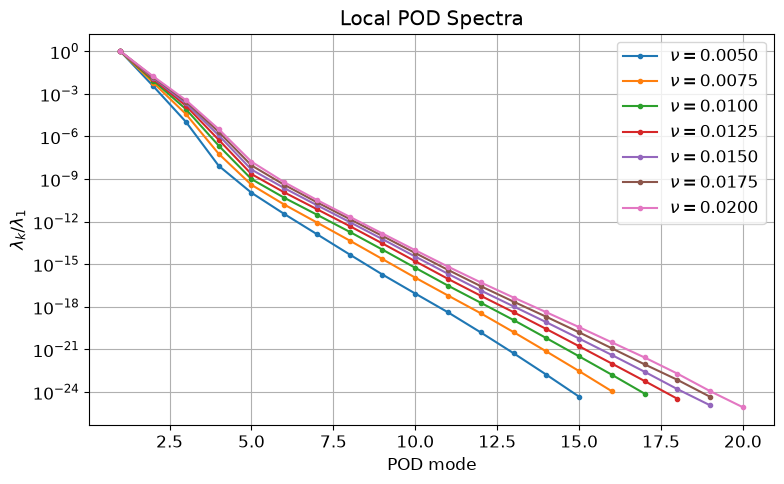

In [28]:
fig, axis = plt.subplots()

for pod_result in local_pod_results:
    normalized_eigenvalues = (
        pod_result.eigenvalues
        / pod_result.eigenvalues[0]
    )

    mode_indices = np.arange(
        1,
        pod_result.numerical_rank + 1,
    )

    axis.semilogy(
        mode_indices,
        normalized_eigenvalues,
        marker="o",
        markersize=3,
        label=fr"$\nu={pod_result.diffusivity:.4f}$",
    )

axis.set_xlabel("POD mode")
axis.set_ylabel(r"$\lambda_k / \lambda_1$")
axis.set_title("Local POD Spectra")
axis.grid(True)
axis.legend()

fig.tight_layout()
plt.show()

## 5.4 Energy-Based Dimension Selection

For each training parameter, define the cumulative POD energy:

$$
E_i(k)
=
\frac{
\displaystyle\sum_{j=1}^{k}\lambda_j^{(i)}
}{
\displaystyle\sum_{j=1}^{r_i^{\mathrm{num}}}
\lambda_j^{(i)}
},
$$

where $r_i^{\mathrm{num}}$ denotes the numerical rank of the local snapshot ensemble.

Given a prescribed threshold $\eta$, the local reduced dimension is defined as:

$$
r_i
=
\min
\left\{
k:
E_i(k)\geq\eta
\right\}.
$$

A threshold of $\eta=0.9999$ is used below, corresponding to a minimum captured POD energy of $99.99\%$.

In [29]:
POD_ENERGY_THRESHOLD = 0.9999

local_energy_dimensions = np.array(
    [
        pod_result.dimension_for_energy(
            POD_ENERGY_THRESHOLD
        )
        for pod_result in local_pod_results
    ],
    dtype=np.int64,
)

for pod_result, local_dimension in zip(
    local_pod_results,
    local_energy_dimensions,
    strict=True,
):
    captured_energy = pod_result.cumulative_energy[
        local_dimension - 1
    ]

    print(
        f"nu = {pod_result.diffusivity:.5f} | "
        f"r_i = {local_dimension:2d} | "
        f"captured energy = {captured_energy:.8f}"
    )

nu = 0.00500 | r_i =  2 | captured energy = 0.99998928
nu = 0.00750 | r_i =  2 | captured energy = 0.99996213
nu = 0.01000 | r_i =  2 | captured energy = 0.99991618
nu = 0.01250 | r_i =  3 | captured energy = 0.99999942
nu = 0.01500 | r_i =  3 | captured energy = 0.99999881
nu = 0.01750 | r_i =  3 | captured energy = 0.99999791
nu = 0.02000 | r_i =  3 | captured energy = 0.99999675


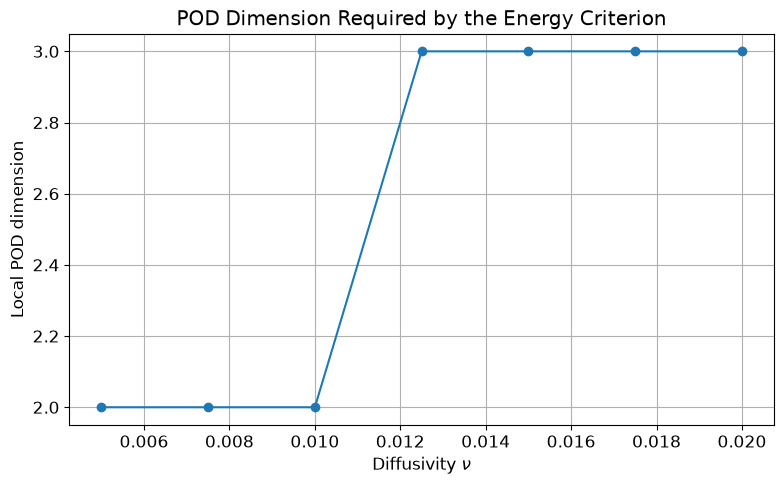

In [30]:
fig, axis = plt.subplots()

axis.plot(
    training_diffusivities,
    local_energy_dimensions,
    marker="o",
)

axis.set_xlabel(r"Diffusivity $\nu$")
axis.set_ylabel("Local POD dimension")
axis.set_title(
    "POD Dimension Required by the Energy Criterion"
)
axis.grid(True)

fig.tight_layout()
plt.show()

## 5.5 Common Reduced Dimension

Grassmann interpolation requires all reduced subspaces to have the same dimension. A Grassmann manifold $G_r(\mathbb{R}^{n_h})$ contains all $r$-dimensional subspaces of $\mathbb{R}^{n_h}$.

Since the local energy criterion may give different dimensions $r_1,\ldots,r_N$, we define

$$
\boxed{
r
=
\max_{i=1,\ldots,N} r_i.
}
$$

Equivalently,

$$
r
=
\min
\left\{
k:
\min_i E_i(k)\geq\eta
\right\}.
$$

Thus, $r$ is the smallest common dimension that satisfies the energy threshold for every training parameter. This ensures that all local POD subspaces belong to the same Grassmann manifold while preserving at least the prescribed POD energy.

In [31]:
common_reduced_dimension = int(
    np.max(local_energy_dimensions)
)

minimum_numerical_rank = min(
    pod_result.numerical_rank
    for pod_result in local_pod_results
)

if common_reduced_dimension > minimum_numerical_rank:
    raise RuntimeError(
        "The requested common reduced dimension exceeds the numerical "
        "rank of at least one local snapshot ensemble. A common "
        "Grassmann dimension cannot be defined without introducing "
        "arbitrary directions."
    )

common_captured_energies = np.array(
    [
        pod_result.cumulative_energy[
            common_reduced_dimension - 1
        ]
        for pod_result in local_pod_results
    ],
    dtype=np.float64,
)

if np.min(common_captured_energies) < (
    POD_ENERGY_THRESHOLD
    - 10.0 * np.finfo(np.float64).eps
):
    raise RuntimeError(
        "The common reduced dimension does not satisfy the requested "
        "energy threshold for every training parameter."
    )

print(
    f"Common reduced dimension : "
    f"{common_reduced_dimension}"
)
print(
    f"Minimum captured energy  : "
    f"{np.min(common_captured_energies):.8f}"
)
print(
    f"Maximum captured energy  : "
    f"{np.max(common_captured_energies):.8f}"
)

Common reduced dimension : 3
Minimum captured energy  : 0.99999675
Maximum captured energy  : 0.99999999


## 5.6 Common-Dimension POD Subspaces

Each local POD basis is now truncated to the common dimension $r$:

$$
\Phi_i
=
\begin{bmatrix}
\phi_1^{(i)}
&
\cdots
&
\phi_r^{(i)}
\end{bmatrix}
\in
\mathbb{R}^{n_h\times r}.
$$

By construction, $\Phi_i^T M\Phi_i=I_r$, and every reduced space $\mathcal{U}_i = \operatorname{Im}(\Phi_i)$ has dimension $r$. The collection $\mathcal{U}_1,\ldots,\mathcal{U}_N$ can therefore be interpreted as a set of training points in a common Grassmann manifold.

The truncated bases are then checked numerically to verify that the $M$-orthonormality condition is preserved.

In [32]:
local_pod_bases = [
    pod_result.basis[
        :,
        :common_reduced_dimension,
    ].copy()
    for pod_result in local_pod_results
]

identity_reduced = np.eye(
    common_reduced_dimension
)

for pod_result, pod_basis in zip(
    local_pod_results,
    local_pod_bases,
    strict=True,
):
    gram_matrix = (
        pod_basis.T
        @ (mass_matrix_csr @ pod_basis)
    )

    orthonormality_error = np.max(
        np.abs(
            gram_matrix - identity_reduced
        )
    )

    print(
        f"nu = {pod_result.diffusivity:.5f} | "
        f"shape = {pod_basis.shape} | "
        f"||Phi^T M Phi - I||_max = "
        f"{orthonormality_error:.3e}"
    )

nu = 0.00500 | shape = (961, 3) | ||Phi^T M Phi - I||_max = 8.882e-16
nu = 0.00750 | shape = (961, 3) | ||Phi^T M Phi - I||_max = 4.441e-16
nu = 0.01000 | shape = (961, 3) | ||Phi^T M Phi - I||_max = 8.882e-16
nu = 0.01250 | shape = (961, 3) | ||Phi^T M Phi - I||_max = 6.661e-16
nu = 0.01500 | shape = (961, 3) | ||Phi^T M Phi - I||_max = 1.110e-15
nu = 0.01750 | shape = (961, 3) | ||Phi^T M Phi - I||_max = 8.882e-16
nu = 0.02000 | shape = (961, 3) | ||Phi^T M Phi - I||_max = 6.661e-16


## 5.7 Projection Accuracy at the Common Dimension

The common reduced dimension is selected from the POD energy criterion. We now evaluate the corresponding projection error in the $M$-norm.

For an $M$-orthonormal basis $\Phi_i$, the orthogonal projection of the snapshot matrix is:

$$
\widetilde S_i
=
\Phi_i\Phi_i^TMS_i.
$$

The relative projection error is

$$
\varepsilon_i^{\mathrm{POD}}
=
\left(
\frac{
\displaystyle
\sum_{j=1}^{N_s}
\left\|
s_j^{(i)}
-
\widetilde s_j^{(i)}
\right\|_M^2
}{
\displaystyle
\sum_{j=1}^{N_s}
\left\|
s_j^{(i)}
\right\|_M^2
}
\right)^{1/2}.
$$

For an exact POD decomposition,

$$
\varepsilon_i^{\mathrm{POD}}
=
\sqrt{1-E_i(r)}.
$$

The direct projection error is compared with this spectral estimate to verify numerical consistency.

In [33]:
def relative_ensemble_projection_error(
    snapshots: NDArray[np.float64],
    basis: NDArray[np.float64],
    mass_matrix: sparse.spmatrix,
) -> float:
    """Compute the relative mass-weighted POD ensemble projection error.

    Parameters
    ----------
    snapshots
        Snapshot matrix with shape ``(num_dofs, num_snapshots)``.
    basis
        Mass-orthonormal reduced basis with shape
        ``(num_dofs, reduced_dimension)``.
    mass_matrix
        Finite element mass matrix.

    Returns
    -------
    float
        Relative root-mean-square projection error over the complete
        snapshot ensemble.

    Raises
    ------
    ValueError
        If matrix dimensions are inconsistent or the snapshot ensemble has
        negligible total energy.
    """
    if snapshots.ndim != 2 or basis.ndim != 2:
        raise ValueError(
            "snapshots and basis must both be two-dimensional."
        )

    if snapshots.shape[0] != basis.shape[0]:
        raise ValueError(
            "snapshots and basis must have the same spatial dimension."
        )

    if mass_matrix.shape != (
        snapshots.shape[0],
        snapshots.shape[0],
    ):
        raise ValueError(
            "The mass matrix has incompatible dimensions."
        )

    mass_weighted_snapshots = mass_matrix @ snapshots

    reduced_coordinates = (
        basis.T @ mass_weighted_snapshots
    )

    projected_snapshots = (
        basis @ reduced_coordinates
    )

    residuals = snapshots - projected_snapshots

    mass_weighted_residuals = (
        mass_matrix @ residuals
    )

    squared_error = float(
        np.einsum(
            "ij,ij->",
            residuals,
            mass_weighted_residuals,
            optimize=True,
        )
    )

    squared_reference_norm = float(
        np.einsum(
            "ij,ij->",
            snapshots,
            mass_weighted_snapshots,
            optimize=True,
        )
    )

    if squared_reference_norm <= np.finfo(np.float64).tiny:
        raise ValueError(
            "The snapshot ensemble has negligible total energy."
        )

    return float(
        np.sqrt(
            max(squared_error, 0.0)
            / squared_reference_norm
        )
    )

In [34]:
projection_errors = np.empty(
    len(training_results),
    dtype=np.float64,
)

spectral_errors = np.sqrt(
    np.maximum(
        1.0 - common_captured_energies,
        0.0,
    )
)

for parameter_index, (
    fom_result,
    pod_basis,
) in enumerate(
    zip(
        training_results,
        local_pod_bases,
        strict=True,
    )
):
    projection_errors[parameter_index] = (
        relative_ensemble_projection_error(
            snapshots=fom_result.snapshots,
            basis=pod_basis,
            mass_matrix=mass_matrix_csr,
        )
    )

    print(
        f"nu = {fom_result.diffusivity:.5f} | "
        f"direct error = "
        f"{projection_errors[parameter_index]:.3e} | "
        f"spectral error = "
        f"{spectral_errors[parameter_index]:.3e}"
    )
    
    
projection_consistency_error = np.max(
    np.abs(
        projection_errors
        - spectral_errors
    )
)

print(
    "\nMaximum spectral/projection discrepancy: "
    f"{projection_consistency_error:.3e}"
)

nu = 0.00500 | direct error = 9.341e-05 | spectral error = 9.341e-05
nu = 0.00750 | direct error = 2.462e-04 | spectral error = 2.462e-04
nu = 0.01000 | direct error = 4.749e-04 | spectral error = 4.749e-04
nu = 0.01250 | direct error = 7.637e-04 | spectral error = 7.637e-04
nu = 0.01500 | direct error = 1.093e-03 | spectral error = 1.093e-03
nu = 0.01750 | direct error = 1.445e-03 | spectral error = 1.445e-03
nu = 0.02000 | direct error = 1.803e-03 | spectral error = 1.803e-03

Maximum spectral/projection discrepancy: 2.882e-13


---

# 6. Mass-Weighted Grassmann Geometry

## 6.1 Transformation to Euclidean Coordinates


The local POD bases are $M$-orthonormal, $\Phi_i^T M \Phi_i = I_r$, whereas standard Grassmann formulas assume Euclidean-orthonormal bases.

Using the Cholesky factorization $M = R^T R$, where $R$ is upper triangular, we define the transformed basis:

$$
Y_i = R\Phi_i.
$$

It follows that

$$
Y_i^T Y_i
=
\Phi_i^T R^T R\Phi_i
=
\Phi_i^T M\Phi_i
=
I_r.
$$



Thus, each $Y_i$ is a Euclidean-orthonormal representative of the same reduced subspace.

Moreover, for any two POD bases, $Y_i^T Y_j = \Phi_i^T M\Phi_j$. Thus, the transformation preserves the mass-weighted inner products between reduced directions.

All Grassmann operations are therefore performed on the transformed bases $Y_i$. After interpolation, the basis is mapped back to finite element coordinates by solving $R\Phi = Y$, without explicitly forming $R^{-1}$.

The Euclidean orthonormality of each transformed basis is checked numerically.

In [35]:
GRASSMANN_ORTHONORMALITY_TOLERANCE = 1.0e-12
GRASSMANN_ROUND_TRIP_TOLERANCE = 1.0e-12


def map_basis_to_euclidean_coordinates(
    basis: NDArray[np.float64],
    mass_cholesky_factor: NDArray[np.float64],
) -> NDArray[np.float64]:
    """Map a mass-orthonormal basis to Euclidean coordinates.

    If ``M = R.T @ R`` and ``basis.T @ M @ basis = I``, the returned
    matrix ``R @ basis`` has Euclidean-orthonormal columns.

    Parameters
    ----------
    basis
        Reduced basis with shape ``(num_dofs, reduced_dimension)``.
    mass_cholesky_factor
        Upper-triangular Cholesky factor ``R`` satisfying
        ``M = R.T @ R``.

    Returns
    -------
    NDArray[np.float64]
        Basis represented in Euclidean coordinates.

    Raises
    ------
    ValueError
        If the input dimensions are inconsistent.
    """
    if basis.ndim != 2:
        raise ValueError("basis must be a two-dimensional array.")

    if mass_cholesky_factor.ndim != 2:
        raise ValueError(
            "mass_cholesky_factor must be a two-dimensional array."
        )

    if (
        mass_cholesky_factor.shape[0]
        != mass_cholesky_factor.shape[1]
    ):
        raise ValueError(
            "mass_cholesky_factor must be square."
        )

    if mass_cholesky_factor.shape[1] != basis.shape[0]:
        raise ValueError(
            "The Cholesky factor and basis dimensions are inconsistent."
        )

    return mass_cholesky_factor @ basis


def map_basis_to_fem_coordinates(
    euclidean_basis: NDArray[np.float64],
    mass_cholesky_factor: NDArray[np.float64],
) -> NDArray[np.float64]:
    """Map a Euclidean Grassmann representative back to FEM coordinates.

    The transformation solves

    ``R @ Phi = Y``

    without explicitly constructing the inverse of ``R``.

    Parameters
    ----------
    euclidean_basis
        Euclidean-orthonormal basis with shape
        ``(num_dofs, reduced_dimension)``.
    mass_cholesky_factor
        Upper-triangular Cholesky factor ``R``.

    Returns
    -------
    NDArray[np.float64]
        Basis represented in the original finite element coordinates.

    Raises
    ------
    ValueError
        If the input dimensions are inconsistent.
    """
    if euclidean_basis.ndim != 2:
        raise ValueError(
            "euclidean_basis must be a two-dimensional array."
        )

    if (
        mass_cholesky_factor.shape[0]
        != mass_cholesky_factor.shape[1]
    ):
        raise ValueError(
            "mass_cholesky_factor must be square."
        )

    if (
        mass_cholesky_factor.shape[0]
        != euclidean_basis.shape[0]
    ):
        raise ValueError(
            "The Cholesky factor and basis dimensions are inconsistent."
        )

    return linalg.solve_triangular(
        mass_cholesky_factor,
        euclidean_basis,
        lower=False,
        check_finite=False,
    )

In [36]:
euclidean_pod_bases = [
    map_basis_to_euclidean_coordinates(
        basis=pod_basis,
        mass_cholesky_factor=mass_cholesky_factor,
    )
    for pod_basis in local_pod_bases
]

for pod_result, euclidean_basis in zip(
    local_pod_results,
    euclidean_pod_bases,
    strict=True,
):
    gram_matrix = euclidean_basis.T @ euclidean_basis

    orthonormality_error = float(
        np.max(
            np.abs(
                gram_matrix - identity_reduced
            )
        )
    )

    if (
        orthonormality_error
        > GRASSMANN_ORTHONORMALITY_TOLERANCE
    ):
        raise RuntimeError(
            "The transformed POD basis is not sufficiently "
            "Euclidean-orthonormal: "
            f"error = {orthonormality_error:.3e}."
        )

    print(
        f"nu = {pod_result.diffusivity:.5f} | "
        f"||Y^T Y - I||_max = "
        f"{orthonormality_error:.3e}"
    )

nu = 0.00500 | ||Y^T Y - I||_max = 1.332e-15
nu = 0.00750 | ||Y^T Y - I||_max = 4.441e-16
nu = 0.01000 | ||Y^T Y - I||_max = 6.661e-16
nu = 0.01250 | ||Y^T Y - I||_max = 8.882e-16
nu = 0.01500 | ||Y^T Y - I||_max = 1.110e-15
nu = 0.01750 | ||Y^T Y - I||_max = 1.110e-15
nu = 0.02000 | ||Y^T Y - I||_max = 8.882e-16


## 6.2 Numerical Verification of the Coordinate Isometry

The Cholesky transformation should preserve the pairwise inner-product matrices
between reduced bases:

$$
\Phi_i^T M\Phi_j
=
Y_i^T Y_j.
$$

It should also be numerically reversible:

$$
\Phi_i
\longrightarrow
Y_i=R\Phi_i
\longrightarrow
R^{-1}Y_i
=
\Phi_i.
$$

Both properties are verified below before any Grassmann operation is applied.

In [37]:
maximum_cross_gram_error = 0.0
maximum_round_trip_error = 0.0

for basis_index, (
    fem_basis,
    euclidean_basis,
) in enumerate(
    zip(
        local_pod_bases,
        euclidean_pod_bases,
        strict=True,
    )
):
    recovered_fem_basis = map_basis_to_fem_coordinates(
        euclidean_basis=euclidean_basis,
        mass_cholesky_factor=mass_cholesky_factor,
    )

    relative_round_trip_error = (
        linalg.norm(
            recovered_fem_basis - fem_basis,
            ord="fro",
        )
        / linalg.norm(fem_basis, ord="fro")
    )

    maximum_round_trip_error = max(
        maximum_round_trip_error,
        relative_round_trip_error,
    )

    for second_index in range(len(local_pod_bases)):
        weighted_cross_gram = (
            fem_basis.T
            @ (
                mass_matrix_np
                @ local_pod_bases[second_index]
            )
        )

        euclidean_cross_gram = (
            euclidean_basis.T
            @ euclidean_pod_bases[second_index]
        )

        cross_gram_error = linalg.norm(
            weighted_cross_gram
            - euclidean_cross_gram,
            ord="fro",
        )

        maximum_cross_gram_error = max(
            maximum_cross_gram_error,
            cross_gram_error,
        )

print(
    "Maximum cross-Gram discrepancy : "
    f"{maximum_cross_gram_error:.3e}"
)
print(
    "Maximum relative round-trip error : "
    f"{maximum_round_trip_error:.3e}"
)

Maximum cross-Gram discrepancy : 9.318e-16
Maximum relative round-trip error : 2.681e-16


In [38]:
if (
    maximum_round_trip_error
    > GRASSMANN_ROUND_TRIP_TOLERANCE
):
    raise RuntimeError(
        "The FEM-to-Euclidean coordinate transformation failed "
        "the round-trip consistency check."
    )

if (
    maximum_cross_gram_error
    > GRASSMANN_ROUND_TRIP_TOLERANCE
):
    raise RuntimeError(
        "The Cholesky transformation does not preserve the "
        "reduced cross-Gram matrices to the requested tolerance."
    )

## 6.3 Principal Angles and Grassmann Distance

Let $Y_1,Y_2\in\mathbb{R}^{n_h\times r}$ be Euclidean-orthonormal
representatives of two reduced subspaces.

The singular values of

$$
Y_1^TY_2
$$

determine their principal angles:

$$
\theta_k
=
\arccos(\sigma_k),
\qquad
k=1,\ldots,r.
$$

The canonical geodesic distance on the Grassmann manifold is then

$$
d_G(\mathcal{U}_1,\mathcal{U}_2)
=
\left(
\sum_{k=1}^{r}\theta_k^2
\right)^{1/2}.
$$

Unlike a direct norm between basis matrices, this quantity depends only on the
subspaces they span and is therefore invariant under orthogonal changes of basis.

In [39]:
def principal_angles(
    first_basis: NDArray[np.float64],
    second_basis: NDArray[np.float64],
) -> NDArray[np.float64]:
    """Compute the principal angles between two Grassmann subspaces.

    Both input matrices must have Euclidean-orthonormal columns and represent
    subspaces of the same dimension.

    Parameters
    ----------
    first_basis
        First orthonormal basis with shape ``(ambient_dimension, r)``.
    second_basis
        Second orthonormal basis with the same shape.

    Returns
    -------
    NDArray[np.float64]
        Principal angles in radians, ordered increasingly.

    Raises
    ------
    ValueError
        If the basis dimensions are incompatible.
    """
    if first_basis.ndim != 2 or second_basis.ndim != 2:
        raise ValueError(
            "Both bases must be two-dimensional arrays."
        )

    if first_basis.shape != second_basis.shape:
        raise ValueError(
            "Both bases must have identical dimensions."
        )

    cross_gram_matrix = first_basis.T @ second_basis

    singular_values = linalg.svdvals(
        cross_gram_matrix,
        check_finite=False,
    )

    # Exact singular values belong to [0, 1]. Clipping only removes
    # floating-point excursions such as 1 + O(machine epsilon).
    singular_values = np.clip(
        singular_values,
        0.0,
        1.0,
    )

    return np.arccos(singular_values)


def grassmann_distance(
    first_basis: NDArray[np.float64],
    second_basis: NDArray[np.float64],
) -> float:
    """Compute the canonical geodesic distance on the Grassmann manifold."""
    angles = principal_angles(
        first_basis=first_basis,
        second_basis=second_basis,
    )

    return float(linalg.norm(angles))

## 6.4 Geometry of the Training Subspaces

Before constructing logarithmic maps, the geometry of the training subspaces is examined using pairwise Grassmann distances and principal angles.

If the POD subspace varies smoothly with the diffusivity, nearby parameter values are expected to produce nearby points on the Grassmann manifold.

The maximum pairwise distance, maximum principal angle, and minimum cross-Gram singular value are used to assess whether the training subspaces remain sufficiently close for the subsequent tangent-space interpolation.

In [40]:
num_training_subspaces = len(euclidean_pod_bases)

pairwise_grassmann_distances = np.zeros(
    (num_training_subspaces, num_training_subspaces),
    dtype=np.float64,
)

pairwise_maximum_angles = np.zeros_like(
    pairwise_grassmann_distances
)

pairwise_minimum_singular_values = np.ones_like(
    pairwise_grassmann_distances
)

for first_index in range(num_training_subspaces):
    for second_index in range(
        first_index + 1,
        num_training_subspaces,
    ):
        first_basis = euclidean_pod_bases[first_index]
        second_basis = euclidean_pod_bases[second_index]

        angles = principal_angles(
            first_basis=first_basis,
            second_basis=second_basis,
        )

        distance = float(linalg.norm(angles))

        cross_singular_values = linalg.svdvals(
            first_basis.T @ second_basis,
            check_finite=False,
        )

        maximum_angle = float(np.max(angles))
        minimum_singular_value = float(
            np.min(cross_singular_values)
        )

        pairwise_grassmann_distances[
            first_index,
            second_index,
        ] = distance
        pairwise_grassmann_distances[
            second_index,
            first_index,
        ] = distance

        pairwise_maximum_angles[
            first_index,
            second_index,
        ] = maximum_angle
        pairwise_maximum_angles[
            second_index,
            first_index,
        ] = maximum_angle

        pairwise_minimum_singular_values[
            first_index,
            second_index,
        ] = minimum_singular_value
        pairwise_minimum_singular_values[
            second_index,
            first_index,
        ] = minimum_singular_value

In [41]:
off_diagonal_mask = ~np.eye(
    num_training_subspaces,
    dtype=bool,
)

maximum_training_distance = float(
    np.max(
        pairwise_grassmann_distances[
            off_diagonal_mask
        ]
    )
)

maximum_training_angle = float(
    np.max(
        pairwise_maximum_angles[
            off_diagonal_mask
        ]
    )
)

minimum_cross_gram_singular_value = float(
    np.min(
        pairwise_minimum_singular_values[
            off_diagonal_mask
        ]
    )
)

print(
    "Maximum pairwise Grassmann distance : "
    f"{maximum_training_distance:.6e}"
)
print(
    "Maximum principal angle             : "
    f"{maximum_training_angle:.6e} rad "
    f"({np.degrees(maximum_training_angle):.3f} deg)"
)
print(
    "Minimum cross-Gram singular value   : "
    f"{minimum_cross_gram_singular_value:.6e}"
)

Maximum pairwise Grassmann distance : 2.999199e-01
Maximum principal angle             : 2.999054e-01 rad (17.183 deg)
Minimum cross-Gram singular value   : 9.553644e-01


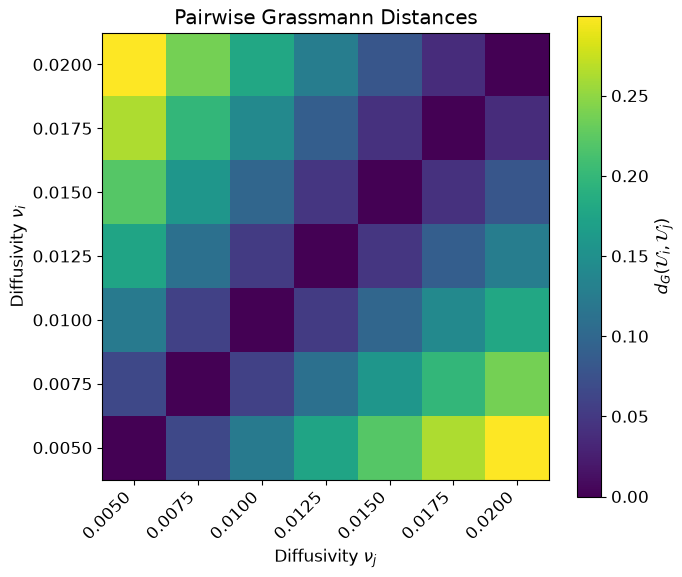

In [42]:
fig, axis = plt.subplots(figsize=(7, 6))

image = axis.imshow(
    pairwise_grassmann_distances,
    origin="lower",
)

axis.set_xticks(
    np.arange(num_training_subspaces)
)
axis.set_yticks(
    np.arange(num_training_subspaces)
)

parameter_labels = [
    f"{diffusivity:.4f}"
    for diffusivity in training_diffusivities
]

axis.set_xticklabels(
    parameter_labels,
    rotation=45,
    ha="right",
)
axis.set_yticklabels(parameter_labels)

axis.set_xlabel(r"Diffusivity $\nu_j$")
axis.set_ylabel(r"Diffusivity $\nu_i$")
axis.set_title("Pairwise Grassmann Distances")

fig.colorbar(
    image,
    ax=axis,
    label=r"$d_G(\mathcal{U}_i,\mathcal{U}_j)$",
)

fig.tight_layout()
plt.show()

## 6.5 Admissibility of the Grassmann Logarithm

The Amsallem-Farhat logarithmic map from a reference basis $Y_r$ to another basis $Y_i$ involves the matrix $Y_r^T Y_i$.

This matrix must be nonsingular. Its singular values are the cosines of the principal angles between the corresponding subspaces, so:

$$
Y_r^T Y_i
\text{ is nonsingular}
\quad\Longleftrightarrow\quad
\theta_{\max}<\frac{\pi}{2}.
$$

The smallest singular value of each pairwise cross-Gram matrix is checked before applying the logarithmic map. Values close to zero indicate proximity to the boundary of the logarithm's local domain and potential numerical instability.

In [43]:
LOGARITHM_SINGULARITY_TOLERANCE = 1.0e-10

if (
    minimum_cross_gram_singular_value
    <= LOGARITHM_SINGULARITY_TOLERANCE
):
    raise RuntimeError(
        "At least one pair of training subspaces is too close to the "
        "singular boundary of the Grassmann logarithm. "
        "The corresponding cross-Gram matrix is nearly singular."
    )

print(
    "All pairwise training cross-Gram matrices are safely "
    "nonsingular."
)

All pairwise training cross-Gram matrices are safely nonsingular.


---

# 7. Grassmann Logarithm and Exponential Maps

The Amsallem--Farhat interpolation method relies on two geometric operations:

1. the Grassmann logarithm, which maps a subspace to the tangent space at a
   chosen reference subspace;
2. the Grassmann exponential, which maps a tangent vector back to the
   Grassmann manifold.

Let $Y_r,Y_i\in\mathbb{R}^{n_h\times r}$ satisfying $Y_r^TY_r=Y_i^TY_i=I_r$, represent two points of the Grassmann manifold. Provided that $Y_r^T Y_i$ is nonsingular, define:

$$
A_i
=
Y_i(Y_r^TY_i)^{-1}
-
Y_r.
$$

Let $A_i = U_i\Sigma_iV_i^T$ be a singular value decomposition. The logarithmic map is represented by:

$$
\boxed{
\Gamma_i
=
U_i
\arctan(\Sigma_i)
V_i^T.
}
$$

The matrix $\Gamma_i$ belongs to the horizontal representation of the tangent
space at $Y_r$ and therefore satisfies $Y_r^T\Gamma_i=0$.

Conversely, let $\Gamma = U\Theta V^T$ be the SVD of a tangent vector at $Y_r$. A convenient
orthonormal representative of its Grassmann exponential is:

$$
\boxed{
\operatorname{Exp}_{Y_r}(\Gamma)
=
\left[
Y_rV\cos(\Theta)
+
U\sin(\Theta)
\right]V^T.
}
$$

The final multiplication by $V^T$ does not change the represented subspace, but
it ensures that the zero tangent vector maps back to the original representative
$Y_r$ rather than to an arbitrary rotated basis of the same subspace.

The Euclidean orthonormality of each Grassmann representative is checked numerically before applying these maps.

In [44]:
GRASSMANN_BASIS_TOLERANCE = 1.0e-10
GRASSMANN_TANGENT_TOLERANCE = 1.0e-10
GRASSMANN_LOG_SINGULARITY_TOLERANCE = 1.0e-10


def validate_orthonormal_basis(
    basis: NDArray[np.float64],
    *,
    tolerance: float = GRASSMANN_BASIS_TOLERANCE,
) -> None:
    """Validate a Euclidean-orthonormal Grassmann representative.

    Parameters
    ----------
    basis
        Candidate basis with shape ``(ambient_dimension, reduced_dimension)``.
    tolerance
        Maximum admissible orthonormality error.

    Raises
    ------
    ValueError
        If the basis is malformed or contains non-finite values.
    RuntimeError
        If the columns are not sufficiently orthonormal.
    """
    if basis.ndim != 2:
        raise ValueError(
            "A Grassmann representative must be a two-dimensional array."
        )

    ambient_dimension, reduced_dimension = basis.shape

    if reduced_dimension == 0:
        raise ValueError(
            "A Grassmann representative must contain at least one vector."
        )

    if reduced_dimension > ambient_dimension:
        raise ValueError(
            "The reduced dimension cannot exceed the ambient dimension."
        )

    if not np.all(np.isfinite(basis)):
        raise ValueError(
            "The Grassmann representative contains non-finite values."
        )

    gram_matrix = basis.T @ basis

    orthonormality_error = float(
        linalg.norm(
            gram_matrix - np.eye(reduced_dimension),
            ord=2,
        )
    )

    if orthonormality_error > tolerance:
        raise RuntimeError(
            "The Grassmann representative is not sufficiently "
            "orthonormal: "
            f"error = {orthonormality_error:.3e}."
        )

## 7.1 Grassmann Logarithm

The logarithmic map sends a target subspace to the tangent space at a reference subspace.

Instead of explicitly computing $(Y_r^T Y_i)^{-1}$, the corresponding linear system is solved for better numerical stability.

The resulting tangent vector satisfies $Y_r^T\Gamma_i = 0$.

Its singular values are the principal angles between the reference and target subspaces. Therefore,

$$
\|\Gamma_i\|_F
=
d_G(\mathcal{U}_r,\mathcal{U}_i).
$$

These properties provide numerical checks for the logarithmic map.

In [45]:
def grassmann_logarithm(
    reference_basis: NDArray[np.float64],
    target_basis: NDArray[np.float64],
) -> NDArray[np.float64]:
    """Compute the Grassmann logarithm at a reference subspace.

    The returned matrix is the horizontal tangent representative

    ``Gamma = Log_reference(target)``.

    Parameters
    ----------
    reference_basis
        Euclidean-orthonormal reference basis with shape
        ``(ambient_dimension, reduced_dimension)``.
    target_basis
        Euclidean-orthonormal target basis with the same shape.

    Returns
    -------
    NDArray[np.float64]
        Horizontal tangent vector at ``reference_basis``.

    Raises
    ------
    ValueError
        If the basis dimensions are incompatible.
    RuntimeError
        If either basis is not orthonormal or if the logarithmic map approaches
        its singular boundary.
    """
    validate_orthonormal_basis(reference_basis)
    validate_orthonormal_basis(target_basis)

    if reference_basis.shape != target_basis.shape:
        raise ValueError(
            "Reference and target bases must have identical dimensions."
        )

    cross_gram_matrix = reference_basis.T @ target_basis

    cross_singular_values = linalg.svdvals(
        cross_gram_matrix,
        check_finite=False,
    )

    minimum_singular_value = float(
        np.min(cross_singular_values)
    )

    if (
        minimum_singular_value
        <= GRASSMANN_LOG_SINGULARITY_TOLERANCE
    ):
        raise RuntimeError(
            "The Grassmann logarithm is numerically ill-defined because "
            "the reference/target cross-Gram matrix is nearly singular. "
            f"Minimum singular value = {minimum_singular_value:.3e}."
        )

    # Compute target_basis @ inv(cross_gram_matrix) without explicitly
    # forming the inverse:
    #
    # X = target_basis @ inv(C)
    # <=> C.T @ X.T = target_basis.T.
    aligned_target = linalg.solve(
        cross_gram_matrix.T,
        target_basis.T,
        assume_a="gen",
        check_finite=False,
    ).T

    logarithm_argument = (
        aligned_target - reference_basis
    )

    left_singular_vectors, singular_values, right_singular_vectors_t = (
        linalg.svd(
            logarithm_argument,
            full_matrices=False,
            check_finite=False,
            lapack_driver="gesdd",
        )
    )

    tangent_angles = np.arctan(singular_values)

    tangent_vector = (
        left_singular_vectors
        * tangent_angles[np.newaxis, :]
    ) @ right_singular_vectors_t

    tangency_error = float(
        linalg.norm(
            reference_basis.T @ tangent_vector,
            ord=2,
        )
    )

    if tangency_error > GRASSMANN_TANGENT_TOLERANCE:
        raise RuntimeError(
            "The logarithmic map failed the tangent-space condition: "
            f"||Y_ref.T @ Gamma||_2 = {tangency_error:.3e}."
        )

    return tangent_vector

## 7.2 Grassmann Exponential

The exponential map sends a tangent vector back to the Grassmann manifold.

For a tangent vector $\Gamma = U\Theta V^T$, the geodesic starting from the reference subspace is represented by:

$$
Y(t)
=
\left[
Y_rV\cos(t\Theta)
+
U\sin(t\Theta)
\right]V^T.
$$

Evaluating this geodesic at $t=1$ gives the exponential map.

The implementation verifies both the tangent-space condition of the input and
the orthonormality of the resulting basis.

In [46]:
def grassmann_exponential(
    reference_basis: NDArray[np.float64],
    tangent_vector: NDArray[np.float64],
) -> NDArray[np.float64]:
    """Compute the Grassmann exponential at a reference subspace.

    Parameters
    ----------
    reference_basis
        Euclidean-orthonormal reference basis with shape
        ``(ambient_dimension, reduced_dimension)``.
    tangent_vector
        Horizontal tangent representative with the same shape and satisfying
        ``reference_basis.T @ tangent_vector = 0``.

    Returns
    -------
    NDArray[np.float64]
        Euclidean-orthonormal representative of the exponential image.

    Raises
    ------
    ValueError
        If the input dimensions are incompatible or contain non-finite values.
    RuntimeError
        If the tangent-space or output-orthonormality conditions fail.
    """
    validate_orthonormal_basis(reference_basis)

    if tangent_vector.ndim != 2:
        raise ValueError(
            "tangent_vector must be a two-dimensional array."
        )

    if tangent_vector.shape != reference_basis.shape:
        raise ValueError(
            "The tangent vector and reference basis must have "
            "identical dimensions."
        )

    if not np.all(np.isfinite(tangent_vector)):
        raise ValueError(
            "The tangent vector contains non-finite values."
        )

    tangency_error = float(
        linalg.norm(
            reference_basis.T @ tangent_vector,
            ord=2,
        )
    )

    if tangency_error > GRASSMANN_TANGENT_TOLERANCE:
        raise RuntimeError(
            "The supplied matrix does not belong to the horizontal "
            "tangent space: "
            f"||Y_ref.T @ Gamma||_2 = {tangency_error:.3e}."
        )

    left_singular_vectors, tangent_angles, right_singular_vectors_t = (
        linalg.svd(
            tangent_vector,
            full_matrices=False,
            check_finite=False,
            lapack_driver="gesdd",
        )
    )

    right_singular_vectors = right_singular_vectors_t.T

    cosine_angles = np.cos(tangent_angles)
    sine_angles = np.sin(tangent_angles)

    geodesic_basis = (
        reference_basis
        @ (
            right_singular_vectors
            * cosine_angles[np.newaxis, :]
        )
        + left_singular_vectors
        * sine_angles[np.newaxis, :]
    ) @ right_singular_vectors_t

    validate_orthonormal_basis(
        geodesic_basis,
        tolerance=GRASSMANN_BASIS_TOLERANCE,
    )

    return geodesic_basis

## 7.3 Fundamental Consistency Tests

The logarithmic and exponential maps are first tested at the reference point.

They must satisfy:

$$
\operatorname{Log}_{Y}(Y)=0
\qquad
\operatorname{Exp}_{Y}(0)=Y.
$$

These identities are checked numerically to verify the implementation of both maps.

In [47]:
test_reference_basis = euclidean_pod_bases[0]

zero_logarithm = grassmann_logarithm(
    reference_basis=test_reference_basis,
    target_basis=test_reference_basis,
)

zero_tangent = np.zeros_like(
    test_reference_basis
)

zero_exponential = grassmann_exponential(
    reference_basis=test_reference_basis,
    tangent_vector=zero_tangent,
)

zero_logarithm_error = float(
    linalg.norm(
        zero_logarithm,
        ord="fro",
    )
)

zero_exponential_error = float(
    linalg.norm(
        zero_exponential - test_reference_basis,
        ord="fro",
    )
)

print(
    "||Log_Y(Y)||_F                 : "
    f"{zero_logarithm_error:.3e}"
)
print(
    "||Exp_Y(0) - Y||_F            : "
    f"{zero_exponential_error:.3e}"
)

||Log_Y(Y)||_F                 : 1.393e-15
||Exp_Y(0) - Y||_F            : 0.000e+00


## 7.4 Logarithm Norm and Geodesic Distance

For the canonical Grassmann metric, the singular values of the logarithmic tangent vector are the principal angles between the two subspaces. Therefore,

$$
\boxed{
\left\|
\operatorname{Log}_{\mathcal U_i}(\mathcal U_j)
\right\|_F
=
d_G(\mathcal U_i,\mathcal U_j).
}
$$

This relation is checked for every pair of training subspaces, together with the tangent-space condition.

In [48]:
maximum_log_distance_discrepancy = 0.0
maximum_tangency_error = 0.0

for reference_index in range(num_training_subspaces):
    reference_basis = euclidean_pod_bases[
        reference_index
    ]

    for target_index in range(num_training_subspaces):
        target_basis = euclidean_pod_bases[
            target_index
        ]

        tangent_vector = grassmann_logarithm(
            reference_basis=reference_basis,
            target_basis=target_basis,
        )

        logarithm_norm = float(
            linalg.norm(
                tangent_vector,
                ord="fro",
            )
        )

        geometric_distance = grassmann_distance(
            first_basis=reference_basis,
            second_basis=target_basis,
        )

        distance_discrepancy = abs(
            logarithm_norm - geometric_distance
        )

        tangency_error = float(
            linalg.norm(
                reference_basis.T @ tangent_vector,
                ord=2,
            )
        )

        maximum_log_distance_discrepancy = max(
            maximum_log_distance_discrepancy,
            distance_discrepancy,
        )

        maximum_tangency_error = max(
            maximum_tangency_error,
            tangency_error,
        )

print(
    "Maximum | ||Log||_F - d_G | : "
    f"{maximum_log_distance_discrepancy:.3e}"
)
print(
    "Maximum tangent-space error : "
    f"{maximum_tangency_error:.3e}"
)

Maximum | ||Log||_F - d_G | : 5.960e-08
Maximum tangent-space error : 1.661e-15


## 7.5 Logarithm--Exponential Round Trip

The logarithm and exponential maps must be local inverses within the
injectivity domain. For every admissible pair of training subspaces, we therefore compute:

$$
\widehat{\mathcal U}_j
=
\operatorname{Exp}_{\mathcal U_i}
\left(
\operatorname{Log}_{\mathcal U_i}(\mathcal U_j)
\right)
$$

and compare the reconstructed subspace with $\mathcal U_j$ using the Grassmann
distance.

The comparison is performed at the subspace level rather than directly between
basis matrices, since different orthonormal bases may represent exactly the same
Grassmann point.

In [49]:
round_trip_distances = np.zeros(
    (num_training_subspaces, num_training_subspaces),
    dtype=np.float64,
)

for reference_index in range(num_training_subspaces):
    reference_basis = euclidean_pod_bases[
        reference_index
    ]

    for target_index in range(num_training_subspaces):
        target_basis = euclidean_pod_bases[
            target_index
        ]

        tangent_vector = grassmann_logarithm(
            reference_basis=reference_basis,
            target_basis=target_basis,
        )

        reconstructed_basis = grassmann_exponential(
            reference_basis=reference_basis,
            tangent_vector=tangent_vector,
        )

        round_trip_distances[
            reference_index,
            target_index,
        ] = grassmann_distance(
            first_basis=reconstructed_basis,
            second_basis=target_basis,
        )

maximum_round_trip_distance = float(
    np.max(round_trip_distances)
)

print(
    "Maximum Exp(Log(.)) Grassmann error: "
    f"{maximum_round_trip_distance:.3e}"
)

Maximum Exp(Log(.)) Grassmann error: 7.300e-08


### Projector-Based Round-Trip Check

The geodesic distance involves an inverse cosine and becomes numerically sensitive when two subspaces are almost identical. A complementary near-zero diagnostic is therefore based on the orthogonal projectors $P_Y=YY^T$.

Two orthonormal bases represent the same Grassmann point if and only if their projectors coincide. The round-trip error can therefore be measured by:

$$
\|P_{\widehat Y}-P_Y\|_F.
$$

In practice, this distance is computed from $\|P_1-P_2\|_F^2 = 2r-2\|Y_1^TY_2\|_F^2$, without explicitly forming the projectors.

In [50]:
def projector_distance(
    first_basis: NDArray[np.float64],
    second_basis: NDArray[np.float64],
) -> float:
    """Compute the Frobenius distance between Grassmann projectors.

    The identity

    ``||P1 - P2||_F^2 = 2r - 2||Y1.T @ Y2||_F^2``

    is used to avoid explicitly constructing dense ambient-space projectors.

    Parameters
    ----------
    first_basis
        First Euclidean-orthonormal basis.
    second_basis
        Second Euclidean-orthonormal basis.

    Returns
    -------
    float
        Frobenius distance between the corresponding orthogonal projectors.
    """
    validate_orthonormal_basis(first_basis)
    validate_orthonormal_basis(second_basis)

    if first_basis.shape != second_basis.shape:
        raise ValueError(
            "Both bases must have identical dimensions."
        )

    reduced_dimension = first_basis.shape[1]

    cross_gram_matrix = (
        first_basis.T @ second_basis
    )

    squared_distance = (
        2.0 * reduced_dimension
        - 2.0
        * linalg.norm(
            cross_gram_matrix,
            ord="fro",
        ) ** 2
    )

    return float(
        np.sqrt(
            max(squared_distance, 0.0)
        )
    )

In [51]:
maximum_projector_round_trip_error = 0.0

for reference_index in range(num_training_subspaces):
    reference_basis = euclidean_pod_bases[
        reference_index
    ]

    for target_index in range(num_training_subspaces):
        target_basis = euclidean_pod_bases[
            target_index
        ]

        tangent_vector = grassmann_logarithm(
            reference_basis=reference_basis,
            target_basis=target_basis,
        )

        reconstructed_basis = grassmann_exponential(
            reference_basis=reference_basis,
            tangent_vector=tangent_vector,
        )

        reconstruction_error = projector_distance(
            first_basis=reconstructed_basis,
            second_basis=target_basis,
        )

        maximum_projector_round_trip_error = max(
            maximum_projector_round_trip_error,
            reconstruction_error,
        )

print(
    "Maximum projector round-trip error: "
    f"{maximum_projector_round_trip_error:.3e}"
)

Maximum projector round-trip error: 8.941e-08


---

# 8. Amsallem--Farhat Interpolation

The geometric building blocks are now combined into the complete
Amsallem--Farhat interpolation procedure.

Given training parameters $\nu_1,\ldots,\nu_N$ and their associated reduced subspaces $\mathcal U_1,\ldots,\mathcal U_N$, the algorithm proceeds in four stages:

1. select a reference subspace associated with the training parameter closest
   to the target parameter $\nu^\star$;
2. map every training subspace to the tangent space at this reference point
   using the Grassmann logarithm;
3. interpolate the resulting tangent matrices as functions of the physical
   parameter;
4. map the interpolated tangent vector back to the Grassmann manifold using
   the exponential map.

For the one-dimensional diffusion parameter considered here, cubic splines are used to interpolate the tangent matrices. They provide a low-degree local interpolation while avoiding the oscillations that may arise with a global polynomial interpolant.

## 8.1 Grassmann Convexity Radius

The convexity radius of the Grassmann manifold is $\pi/4$. Before interpolation, we therefore verify that:

$$
d_G(\mathcal U_i,\mathcal U_j)
<
\frac{\pi}{4},
\qquad
\forall i,j.
$$

This ensures that the training subspaces remain within the convexity radius.

In [52]:
GRASSMANN_CONVEXITY_RADIUS = np.pi / 4.0

if maximum_training_distance >= GRASSMANN_CONVEXITY_RADIUS:
    raise RuntimeError(
        "The training subspaces do not satisfy the prescribed "
        "pairwise convexity condition: "
        f"maximum distance = {maximum_training_distance:.6e}, "
        f"pi/4 = {GRASSMANN_CONVEXITY_RADIUS:.6e}."
    )

print(
    "Maximum training distance : "
    f"{maximum_training_distance:.6e}"
)
print(
    "Convexity threshold pi/4  : "
    f"{GRASSMANN_CONVEXITY_RADIUS:.6e}"
)
print(
    "Geometric admissibility   : satisfied"
)

Maximum training distance : 2.999199e-01
Convexity threshold pi/4  : 7.853982e-01
Geometric admissibility   : satisfied


## 8.2 Reference Subspace Selection

For a target parameter $\nu^\star$, the reference point is selected from the
available training subspaces according to

$$
\nu_r
=
\operatorname*{arg\,min}_{\nu_i}
|\nu^\star-\nu_i|.
$$

The present validation parameters were deliberately chosen away from interval
midpoints, so the nearest training parameter is unique.

The implementation nevertheless checks this explicitly and raises an error if a tie occurs rather than silently selecting one of several equally close reference points.

In [53]:
def select_reference_index(
    training_parameters: NDArray[np.float64],
    target_parameter: float,
) -> int:
    """Select the uniquely closest training parameter.

    Parameters
    ----------
    training_parameters
        Strictly increasing one-dimensional array of training parameters.
    target_parameter
        Parameter at which the reduced subspace is to be interpolated.

    Returns
    -------
    int
        Index of the uniquely closest training parameter.

    Raises
    ------
    ValueError
        If the input parameter set is malformed or if the target lies outside
        the interpolation interval.
    RuntimeError
        If several training parameters are equally close to the target.
    """
    parameters = np.asarray(
        training_parameters,
        dtype=np.float64,
    )

    if parameters.ndim != 1 or parameters.size < 2:
        raise ValueError(
            "training_parameters must be a one-dimensional array "
            "containing at least two values."
        )

    if not np.all(np.isfinite(parameters)):
        raise ValueError(
            "training_parameters contains non-finite values."
        )

    if np.any(np.diff(parameters) <= 0.0):
        raise ValueError(
            "training_parameters must be strictly increasing."
        )

    if not np.isfinite(target_parameter):
        raise ValueError(
            "target_parameter must be finite."
        )

    if not parameters[0] <= target_parameter <= parameters[-1]:
        raise ValueError(
            "The target parameter lies outside the training interval. "
            "Amsallem--Farhat interpolation is restricted here to "
            "interpolation rather than extrapolation."
        )

    parameter_distances = np.abs(
        parameters - target_parameter
    )

    minimum_distance = float(
        np.min(parameter_distances)
    )

    tie_tolerance = (
        100.0
        * np.finfo(np.float64).eps
        * max(
            1.0,
            float(np.max(np.abs(parameters))),
        )
    )

    nearest_indices = np.flatnonzero(
        np.abs(
            parameter_distances - minimum_distance
        )
        <= tie_tolerance
    )

    if nearest_indices.size != 1:
        raise RuntimeError(
            "The nearest reference parameter is not unique. "
            "Choose a target away from an exact midpoint or define an "
            "explicit reference-selection rule."
        )

    return int(nearest_indices[0])

In [54]:
primary_reference_index = select_reference_index(
    training_parameters=training_diffusivities,
    target_parameter=PRIMARY_TARGET_DIFFUSIVITY,
)

primary_reference_diffusivity = float(
    training_diffusivities[primary_reference_index]
)

print(
    f"Target diffusivity    : "
    f"{PRIMARY_TARGET_DIFFUSIVITY:.5f}"
)
print(
    f"Reference diffusivity : "
    f"{primary_reference_diffusivity:.5f}"
)
print(
    f"Reference index       : "
    f"{primary_reference_index}"
)

Target diffusivity    : 0.01350
Reference diffusivity : 0.01250
Reference index       : 3


## 8.3 Training Subspaces in the Reference Tangent Space

Let $Y_r$ denote the Euclidean representative of the selected reference
subspace. Each training subspace is mapped to the same tangent space through

$$
\Gamma_i
=
\operatorname{Log}_{Y_r}(Y_i),
\qquad
i=1,\ldots,N.
$$

Since all matrices $\Gamma_i$ belong to the linear space $\mathcal H_{Y_r}
= \left\{ \Gamma\in\mathbb R^{n_h\times r}: Y_r^T\Gamma=0 \right\}$, standard vector-space interpolation can be applied componentwise.

In particular, the tangent vector associated with the reference subspace is $\Gamma_r = \operatorname{Log}_{Y_r}(Y_r) = 0$.

The zero logarithm at the reference point and the tangent-space condition are checked numerically.

In [55]:
def compute_reference_tangent_data(
    euclidean_bases: list[NDArray[np.float64]],
    reference_index: int,
) -> NDArray[np.float64]:
    """Map all training subspaces to one Grassmann tangent space.

    Parameters
    ----------
    euclidean_bases
        Euclidean-orthonormal representatives of the training subspaces.
    reference_index
        Index of the basis defining the tangent space.

    Returns
    -------
    NDArray[np.float64]
        Tangent matrices with shape
        ``(num_training_parameters, ambient_dimension, reduced_dimension)``.

    Raises
    ------
    ValueError
        If the collection is empty or the reference index is invalid.
    """
    if len(euclidean_bases) == 0:
        raise ValueError(
            "euclidean_bases must contain at least one basis."
        )

    if not 0 <= reference_index < len(euclidean_bases):
        raise ValueError(
            "reference_index is outside the valid range."
        )

    reference_basis = euclidean_bases[
        reference_index
    ]

    tangent_data = np.stack(
        [
            grassmann_logarithm(
                reference_basis=reference_basis,
                target_basis=target_basis,
            )
            for target_basis in euclidean_bases
        ],
        axis=0,
    )

    return tangent_data

primary_reference_basis = euclidean_pod_bases[
    primary_reference_index
]

primary_tangent_data = compute_reference_tangent_data(
    euclidean_bases=euclidean_pod_bases,
    reference_index=primary_reference_index,
)

print(
    f"Tangent dataset shape : "
    f"{primary_tangent_data.shape}"
)

Tangent dataset shape : (7, 961, 3)


In [56]:
reference_tangent_norm = float(
    linalg.norm(
        primary_tangent_data[
            primary_reference_index
        ],
        ord="fro",
    )
)

maximum_training_tangency_error = max(
    float(
        linalg.norm(
            primary_reference_basis.T @ tangent_matrix,
            ord=2,
        )
    )
    for tangent_matrix in primary_tangent_data
)

print(
    "Reference logarithm norm      : "
    f"{reference_tangent_norm:.3e}"
)
print(
    "Maximum training tangency error: "
    f"{maximum_training_tangency_error:.3e}"
)

Reference logarithm norm      : 1.030e-15
Maximum training tangency error: 9.299e-16


## 8.4 Cubic-Spline Interpolation in the Tangent Space

The tangent matrices are interpolated directly as matrix-valued data.

A natural cubic spline $\Gamma(\nu)$ is constructed such that

$$
\Gamma(\nu_i)=\Gamma_i,
\qquad
i=1,\ldots,N.
$$

Since the tangent space is linear, the interpolated matrix remains in the same tangent space up to floating-point error: $Y_r^T\Gamma(\nu^\star)\approx0$. This tangent-space condition is checked numerically after interpolation.

The spline is evaluated only inside the training interval; extrapolation is disabled.

In [57]:
def interpolate_tangent_cubic_spline(
    training_parameters: NDArray[np.float64],
    tangent_data: NDArray[np.float64],
    target_parameter: float,
) -> NDArray[np.float64]:
    """Interpolate Grassmann tangent data with a cubic spline.

    Parameters
    ----------
    training_parameters
        Strictly increasing training parameters with shape
        ``(num_training_parameters,)``.
    tangent_data
        Tangent matrices with shape
        ``(num_training_parameters, ambient_dimension, reduced_dimension)``.
    target_parameter
        Parameter at which the tangent vector is evaluated.

    Returns
    -------
    NDArray[np.float64]
        Interpolated tangent matrix.

    Raises
    ------
    ValueError
        If the training data are inconsistent or the target lies outside the
        training interval.
    """
    parameters = np.asarray(
        training_parameters,
        dtype=np.float64,
    )

    tangent_data = np.asarray(
        tangent_data,
        dtype=np.float64,
    )

    if parameters.ndim != 1:
        raise ValueError(
            "training_parameters must be one-dimensional."
        )

    if tangent_data.ndim != 3:
        raise ValueError(
            "tangent_data must have shape "
            "(num_parameters, ambient_dimension, reduced_dimension)."
        )

    if tangent_data.shape[0] != parameters.size:
        raise ValueError(
            "The number of tangent matrices must match the number "
            "of training parameters."
        )

    if parameters.size < 4:
        raise ValueError(
            "At least four training parameters are required for the "
            "cubic-spline interpolation used in this notebook."
        )

    if np.any(np.diff(parameters) <= 0.0):
        raise ValueError(
            "training_parameters must be strictly increasing."
        )

    if not parameters[0] <= target_parameter <= parameters[-1]:
        raise ValueError(
            "The target parameter lies outside the interpolation interval."
        )

    spline = CubicSpline(
        x=parameters,
        y=tangent_data,
        axis=0,
        bc_type="natural",
        extrapolate=False,
    )

    interpolated_tangent = np.asarray(
        spline(target_parameter),
        dtype=np.float64,
    )

    if not np.all(np.isfinite(interpolated_tangent)):
        raise RuntimeError(
            "The cubic-spline interpolation returned non-finite values."
        )

    return interpolated_tangent

In [58]:
primary_interpolated_tangent = (
    interpolate_tangent_cubic_spline(
        training_parameters=training_diffusivities,
        tangent_data=primary_tangent_data,
        target_parameter=PRIMARY_TARGET_DIFFUSIVITY,
    )
)

primary_interpolated_tangency_error = float(
    linalg.norm(
        primary_reference_basis.T
        @ primary_interpolated_tangent,
        ord=2,
    )
)

primary_interpolated_tangent_norm = float(
    linalg.norm(
        primary_interpolated_tangent,
        ord="fro",
    )
)

print(
    "Interpolated tangent norm  : "
    f"{primary_interpolated_tangent_norm:.6e}"
)
print(
    "Interpolated tangency error: "
    f"{primary_interpolated_tangency_error:.3e}"
)

Interpolated tangent norm  : 1.944850e-02
Interpolated tangency error: 6.616e-16


## 8.5 Exponential Map and Return to Finite Element Coordinates

The interpolated tangent vector is mapped back to the Grassmann manifold:

$$
Y^\star
=
\operatorname{Exp}_{Y_r}
\left(
\Gamma(\nu^\star)
\right).
$$

The resulting Euclidean basis satisfies $(Y^\star)^TY^\star=I$.

Finally, the basis is transformed back to the original finite element
coordinates,

$$
\Phi^\star
=
R^{-1}Y^\star.
$$

Consequently, $(\Phi^\star)^TM\Phi^\star=I$. Both orthonormality conditions are checked numerically.

Here, the complete Amsallem--Farhat procedure is assembled into a single interpolation function that returns the interpolated basis for any target parameter $\nu^\star$ within the training interval.

In [59]:
primary_interpolated_euclidean_basis = (
    grassmann_exponential(
        reference_basis=primary_reference_basis,
        tangent_vector=primary_interpolated_tangent,
    )
)

primary_interpolated_fem_basis = (
    map_basis_to_fem_coordinates(
        euclidean_basis=primary_interpolated_euclidean_basis,
        mass_cholesky_factor=mass_cholesky_factor,
    )
)

euclidean_gram_error = float(
    linalg.norm(
        primary_interpolated_euclidean_basis.T
        @ primary_interpolated_euclidean_basis
        - identity_reduced,
        ord=2,
    )
)

mass_gram_error = float(
    linalg.norm(
        primary_interpolated_fem_basis.T
        @ (
            mass_matrix_np
            @ primary_interpolated_fem_basis
        )
        - identity_reduced,
        ord=2,
    )
)

print(
    "Euclidean orthonormality error : "
    f"{euclidean_gram_error:.3e}"
)
print(
    "FEM mass-orthonormality error  : "
    f"{mass_gram_error:.3e}"
)

Euclidean orthonormality error : 1.365e-15
FEM mass-orthonormality error  : 1.360e-15


In [60]:
@dataclass(frozen=True)
class AmsallemFarhatResult:
    """Result of one Amsallem--Farhat Grassmann interpolation."""

    target_parameter: float
    reference_index: int
    reference_parameter: float
    interpolated_tangent: NDArray[np.float64]
    euclidean_basis: NDArray[np.float64]
    fem_basis: NDArray[np.float64]

    @property
    def reduced_dimension(self) -> int:
        """Return the dimension of the interpolated reduced space."""
        return self.fem_basis.shape[1]

In [61]:
def interpolate_amsallem_farhat(
    training_parameters: NDArray[np.float64],
    euclidean_bases: list[NDArray[np.float64]],
    target_parameter: float,
    mass_cholesky_factor: NDArray[np.float64],
) -> AmsallemFarhatResult:
    """Interpolate a POD subspace using the Amsallem--Farhat method.

    The procedure selects the nearest training subspace as reference, maps all
    training subspaces to its Grassmann tangent space, performs a cubic-spline
    interpolation of the tangent matrices, and returns to the manifold through
    the exponential map.

    Parameters
    ----------
    training_parameters
        Strictly increasing one-dimensional parameter array.
    euclidean_bases
        Euclidean-orthonormal representatives of the training POD subspaces.
    target_parameter
        Parameter at which the reduced subspace is requested.
    mass_cholesky_factor
        Upper-triangular Cholesky factor ``R`` satisfying ``M = R.T @ R``.

    Returns
    -------
    AmsallemFarhatResult
        Reference information together with the interpolated tangent,
        Euclidean basis, and finite element basis.

    Raises
    ------
    ValueError
        If the number of parameters and bases is inconsistent.
    RuntimeError
        If the interpolated tangent vector fails the tangent-space condition.
    """
    parameters = np.asarray(
        training_parameters,
        dtype=np.float64,
    )

    if len(euclidean_bases) != parameters.size:
        raise ValueError(
            "The number of training parameters and Grassmann bases "
            "must be identical."
        )

    reference_index = select_reference_index(
        training_parameters=parameters,
        target_parameter=target_parameter,
    )

    reference_basis = euclidean_bases[
        reference_index
    ]

    tangent_data = compute_reference_tangent_data(
        euclidean_bases=euclidean_bases,
        reference_index=reference_index,
    )

    interpolated_tangent = (
        interpolate_tangent_cubic_spline(
            training_parameters=parameters,
            tangent_data=tangent_data,
            target_parameter=target_parameter,
        )
    )

    tangency_error = float(
        linalg.norm(
            reference_basis.T @ interpolated_tangent,
            ord=2,
        )
    )

    if tangency_error > GRASSMANN_TANGENT_TOLERANCE:
        raise RuntimeError(
            "The interpolated matrix does not satisfy the tangent-space "
            "condition: "
            f"error = {tangency_error:.3e}."
        )

    euclidean_basis = grassmann_exponential(
        reference_basis=reference_basis,
        tangent_vector=interpolated_tangent,
    )

    fem_basis = map_basis_to_fem_coordinates(
        euclidean_basis=euclidean_basis,
        mass_cholesky_factor=mass_cholesky_factor,
    )

    return AmsallemFarhatResult(
        target_parameter=float(target_parameter),
        reference_index=reference_index,
        reference_parameter=float(
            parameters[reference_index]
        ),
        interpolated_tangent=interpolated_tangent,
        euclidean_basis=euclidean_basis,
        fem_basis=fem_basis,
    )

In [62]:
primary_interpolation_result = (
    interpolate_amsallem_farhat(
        training_parameters=training_diffusivities,
        euclidean_bases=euclidean_pod_bases,
        target_parameter=PRIMARY_TARGET_DIFFUSIVITY,
        mass_cholesky_factor=mass_cholesky_factor,
    )
)

print(
    f"Target parameter    : "
    f"{primary_interpolation_result.target_parameter:.5f}"
)
print(
    f"Reference parameter : "
    f"{primary_interpolation_result.reference_parameter:.5f}"
)
print(
    f"Reduced dimension   : "
    f"{primary_interpolation_result.reduced_dimension}"
)

Target parameter    : 0.01350
Reference parameter : 0.01250
Reduced dimension   : 3


## 8.6 Interpolation Check at the Training Parameters

A genuine interpolation scheme must reproduce every training subspace when
evaluated at its own parameter value.

For each $\nu_i$, the complete Amsallem--Farhat procedure is therefore
re-evaluated at $\nu_i$ and the resulting subspace is compared with the original
training subspace.

Because the reference point may change from one parameter to another, this test
validates the complete interpolation pipeline rather than only the cubic spline.

In [63]:
training_reproduction_errors = np.empty(
    training_diffusivities.size,
    dtype=np.float64,
)

for parameter_index, parameter_value in enumerate(
    training_diffusivities
):
    interpolation_result = interpolate_amsallem_farhat(
        training_parameters=training_diffusivities,
        euclidean_bases=euclidean_pod_bases,
        target_parameter=float(parameter_value),
        mass_cholesky_factor=mass_cholesky_factor,
    )

    training_reproduction_errors[
        parameter_index
    ] = projector_distance(
        first_basis=interpolation_result.euclidean_basis,
        second_basis=euclidean_pod_bases[parameter_index],
    )

    print(
        f"nu = {parameter_value:.5f} | "
        f"projector error = "
        f"{training_reproduction_errors[parameter_index]:.3e}"
    )

maximum_training_reproduction_error = float(
    np.max(training_reproduction_errors)
)

print(
    "\nMaximum training reproduction error: "
    f"{maximum_training_reproduction_error:.3e}"
)

nu = 0.00500 | projector error = 5.960e-08
nu = 0.00750 | projector error = 0.000e+00
nu = 0.01000 | projector error = 0.000e+00
nu = 0.01250 | projector error = 5.960e-08
nu = 0.01500 | projector error = 0.000e+00
nu = 0.01750 | projector error = 0.000e+00
nu = 0.02000 | projector error = 0.000e+00

Maximum training reproduction error: 5.960e-08


---

# 9. Interpolated POD--Galerkin Model

The interpolated basis $\Phi^\star \in \mathbb{R}^{n_h\times r}$ is now used to construct a POD--Galerkin Reduced-Order Model at the unseen
parameter $\nu^\star$.

Writing $u_h(t;\nu^\star) \approx \Phi^\star a(t)$, the backward Euler scheme projected onto the interpolated reduced space becomes

$$
\left(
M_r
+
\Delta t\,\nu^\star K_r
\right)
a^{n+1}
=
M_r a^n,
$$

where

$$
M_r
=
(\Phi^\star)^T M\Phi^\star,
\qquad
K_r
=
(\Phi^\star)^T K\Phi^\star.
$$

Since the interpolated basis is mass-orthonormal, $M_r \approx I_r$.

The computed reduced mass matrix is nevertheless retained in the ROM. The mass-orthonormality of the basis and the homogeneous boundary conditions are checked numerically.

The initial reduced coordinates are obtained through the $M$-orthogonal projection of the Full-Order initial condition onto the interpolated subspace.

In [64]:
@dataclass(frozen=True)
class ROMResult:
    """Container for a POD--Galerkin Reduced-Order Model trajectory."""

    diffusivity: float
    time_grid: NDArray[np.float64]
    reduced_coordinates: NDArray[np.float64]
    snapshots: NDArray[np.float64]
    wall_time_seconds: float

    @property
    def final_state(self) -> NDArray[np.float64]:
        """Return the reconstructed final-time state."""
        return self.snapshots[:, -1]

In [65]:
def solve_reduced_order_model(
    diffusivity: float,
    basis: NDArray[np.float64],
    initial_state: NDArray[np.float64],
) -> ROMResult:
    """Solve the POD--Galerkin model associated with a reduced basis.

    The reduced operators are obtained by Galerkin projection of the finite
    element mass and stiffness matrices. The reduced initial condition is the
    mass-orthogonal projection of the Full-Order initial state.

    Parameters
    ----------
    diffusivity
        Strictly positive diffusion coefficient.
    basis
        Mass-orthonormal reduced basis with shape
        ``(num_dofs, reduced_dimension)``.
    initial_state
        Full-Order initial state with shape ``(num_dofs,)``.

    Returns
    -------
    ROMResult
        Reduced coordinates, reconstructed trajectory, and online wall time.

    Raises
    ------
    ValueError
        If the inputs have inconsistent dimensions or invalid values.
    RuntimeError
        If the reduced system is not numerically positive definite.
    """
    if not np.isfinite(diffusivity) or diffusivity <= 0.0:
        raise ValueError(
            "diffusivity must be finite and strictly positive."
        )

    if basis.ndim != 2:
        raise ValueError("basis must be two-dimensional.")

    if initial_state.ndim != 1:
        raise ValueError("initial_state must be one-dimensional.")

    if basis.shape[0] != num_dofs:
        raise ValueError(
            "The reduced basis has an inconsistent spatial dimension."
        )

    if initial_state.shape[0] != num_dofs:
        raise ValueError(
            "The initial state has an inconsistent spatial dimension."
        )

    reduced_dimension = basis.shape[1]

    start_time = time.perf_counter()

    reduced_mass_matrix = (
        basis.T @ (mass_matrix_csr @ basis)
    )

    reduced_stiffness_matrix = (
        basis.T @ (stiffness_matrix_csr @ basis)
    )

    # Symmetrization removes only floating-point antisymmetric components.
    reduced_mass_matrix = 0.5 * (
        reduced_mass_matrix + reduced_mass_matrix.T
    )
    reduced_stiffness_matrix = 0.5 * (
        reduced_stiffness_matrix
        + reduced_stiffness_matrix.T
    )

    initial_reduced_rhs = (
        basis.T @ (mass_matrix_csr @ initial_state)
    )

    try:
        reduced_mass_factor = linalg.cho_factor(
            reduced_mass_matrix,
            lower=False,
            check_finite=False,
        )

        reduced_initial_state = linalg.cho_solve(
            reduced_mass_factor,
            initial_reduced_rhs,
            check_finite=False,
        )

        reduced_system_matrix = (
            reduced_mass_matrix
            + CONFIG.time_step
            * diffusivity
            * reduced_stiffness_matrix
        )

        reduced_system_factor = linalg.cho_factor(
            reduced_system_matrix,
            lower=False,
            check_finite=False,
        )

    except linalg.LinAlgError as error:
        raise RuntimeError(
            "The reduced mass or time-stepping matrix is not "
            "numerically positive definite."
        ) from error

    reduced_coordinates = np.empty(
        (
            reduced_dimension,
            CONFIG.num_time_steps + 1,
        ),
        dtype=np.float64,
    )

    reduced_coordinates[:, 0] = reduced_initial_state

    for time_index in range(1, CONFIG.num_time_steps + 1):
        right_hand_side = (
            reduced_mass_matrix
            @ reduced_coordinates[:, time_index - 1]
        )

        reduced_coordinates[:, time_index] = (
            linalg.cho_solve(
                reduced_system_factor,
                right_hand_side,
                check_finite=False,
            )
        )

    reconstructed_snapshots = (
        basis @ reduced_coordinates
    )

    wall_time_seconds = time.perf_counter() - start_time

    time_grid = np.linspace(
        0.0,
        CONFIG.final_time,
        CONFIG.num_time_steps + 1,
        dtype=np.float64,
    )

    return ROMResult(
        diffusivity=float(diffusivity),
        time_grid=time_grid,
        reduced_coordinates=reduced_coordinates,
        snapshots=reconstructed_snapshots,
        wall_time_seconds=wall_time_seconds,
    )

In [66]:
interpolated_basis = (
    primary_interpolation_result.fem_basis
)

interpolated_reduced_mass_matrix = (
    interpolated_basis.T
    @ (mass_matrix_csr @ interpolated_basis)
)

reduced_mass_error = float(
    linalg.norm(
        interpolated_reduced_mass_matrix
        - np.eye(common_reduced_dimension),
        ord=2,
    )
)

boundary_basis_error = float(
    np.max(
        np.abs(
            interpolated_basis[boundary_dofs, :]
        )
    )
)

print(
    f"||M_r - I||_2              : "
    f"{reduced_mass_error:.3e}"
)
print(
    f"Maximum boundary basis value: "
    f"{boundary_basis_error:.3e}"
)

||M_r - I||_2              : 1.357e-15
Maximum boundary basis value: 7.812e-14


In [67]:
full_order_initial_state = (
    training_results[0].snapshots[:, 0]
)

primary_rom_result = solve_reduced_order_model(
    diffusivity=PRIMARY_TARGET_DIFFUSIVITY,
    basis=interpolated_basis,
    initial_state=full_order_initial_state,
)

print(
    f"Target diffusivity : "
    f"{primary_rom_result.diffusivity:.5f}"
)
print(
    f"Reduced dimension  : "
    f"{common_reduced_dimension}"
)
print(
    f"ROM wall time      : "
    f"{primary_rom_result.wall_time_seconds:.6f} s"
)

Target diffusivity : 0.01350
Reduced dimension  : 3
ROM wall time      : 0.007162 s


---

# 10. Validation at the Unseen Parameter

The interpolated reduced model has been constructed without using any
FOM data at the target diffusivity $\nu^\star = 0.0135$.

The held-out FOM solution is now computed only for validation.

Two aspects are evaluated:


1. **Subspace accuracy:** how close is the interpolated subspace to
   the POD subspace that would have been obtained directly at $\nu^\star$?
2. **Dynamical accuracy:** how accurately does the interpolated POD--Galerkin
   model reproduce the Full-Order trajectory?

To separate interpolation error from POD truncation error, an *oracle POD--Galerkin model* is also constructed using the POD basis computed directly at $\nu^\star$, with the same reduced dimension $r$ as the interpolated model.

In [68]:
target_fom_result = solve_full_order_model(
    diffusivity=PRIMARY_TARGET_DIFFUSIVITY
)

target_pod_result = compute_mass_weighted_pod(
    fom_result=target_fom_result,
    mass_cholesky_factor=mass_cholesky_factor,
)

if target_pod_result.numerical_rank < common_reduced_dimension:
    raise RuntimeError(
        "The held-out POD numerical rank is smaller than the common "
        "reduced dimension."
    )

oracle_fem_basis = target_pod_result.basis[
    :,
    :common_reduced_dimension,
].copy()

oracle_euclidean_basis = (
    map_basis_to_euclidean_coordinates(
        basis=oracle_fem_basis,
        mass_cholesky_factor=mass_cholesky_factor,
    )
)

print(
    f"Target FOM wall time : "
    f"{target_fom_result.wall_time_seconds:.3f} s"
)
print(
    f"Target POD rank      : "
    f"{target_pod_result.numerical_rank}"
)

Target FOM wall time : 0.041 s
Target POD rank      : 18


## 10.1 Interpolated vs Oracle POD Subspace

The interpolated subspace is compared with the POD subspace computed directly from the held-out snapshots.

The comparison is based on the Grassmann distance

$$
d_G
\left(
\widehat{\mathcal U}(\nu^\star),
\mathcal U_{\mathrm{POD}}(\nu^\star)
\right),
$$

together with the projector distance and the maximum principal angle.

In [69]:
interpolated_subspace_distance = grassmann_distance(
    first_basis=primary_interpolation_result.euclidean_basis,
    second_basis=oracle_euclidean_basis,
)

interpolated_projector_distance = projector_distance(
    first_basis=primary_interpolation_result.euclidean_basis,
    second_basis=oracle_euclidean_basis,
)

target_principal_angles = principal_angles(
    first_basis=primary_interpolation_result.euclidean_basis,
    second_basis=oracle_euclidean_basis,
)

print(
    "Grassmann distance       : "
    f"{interpolated_subspace_distance:.6e}"
)
print(
    "Projector distance       : "
    f"{interpolated_projector_distance:.6e}"
)
print(
    "Maximum principal angle  : "
    f"{np.max(target_principal_angles):.6e} rad "
    f"({np.degrees(np.max(target_principal_angles)):.4f} deg)"
)

Grassmann distance       : 1.855652e-05
Projector distance       : 2.624289e-05
Maximum principal angle  : 1.769803e-05 rad (0.0010 deg)


In [70]:
oracle_rom_result = solve_reduced_order_model(
    diffusivity=PRIMARY_TARGET_DIFFUSIVITY,
    basis=oracle_fem_basis,
    initial_state=full_order_initial_state,
)

In [71]:
def relative_snapshot_errors(
    reference_snapshots: NDArray[np.float64],
    approximation_snapshots: NDArray[np.float64],
    mass_matrix: sparse.spmatrix,
) -> NDArray[np.float64]:
    """Compute the relative mass-weighted error at every time step.

    Parameters
    ----------
    reference_snapshots
        Reference trajectory with shape ``(num_dofs, num_snapshots)``.
    approximation_snapshots
        Approximate trajectory with the same shape.
    mass_matrix
        Finite element mass matrix.

    Returns
    -------
    NDArray[np.float64]
        Relative error at every snapshot time.

    Raises
    ------
    ValueError
        If the trajectory dimensions are inconsistent or a reference state has
        negligible mass-weighted norm.
    """
    if reference_snapshots.shape != approximation_snapshots.shape:
        raise ValueError(
            "Reference and approximation trajectories must have "
            "identical dimensions."
        )

    residuals = reference_snapshots - approximation_snapshots

    mass_weighted_reference = (
        mass_matrix @ reference_snapshots
    )
    mass_weighted_residuals = (
        mass_matrix @ residuals
    )

    squared_reference_norms = np.einsum(
        "ij,ij->j",
        reference_snapshots,
        mass_weighted_reference,
        optimize=True,
    )

    squared_error_norms = np.einsum(
        "ij,ij->j",
        residuals,
        mass_weighted_residuals,
        optimize=True,
    )

    if np.any(
        squared_reference_norms
        <= np.finfo(np.float64).tiny
    ):
        raise ValueError(
            "At least one reference snapshot has negligible norm."
        )

    return np.sqrt(
        np.maximum(squared_error_norms, 0.0)
        / squared_reference_norms
    )

In [72]:
interpolated_rom_errors = relative_snapshot_errors(
    reference_snapshots=target_fom_result.snapshots,
    approximation_snapshots=primary_rom_result.snapshots,
    mass_matrix=mass_matrix_csr,
)

oracle_rom_errors = relative_snapshot_errors(
    reference_snapshots=target_fom_result.snapshots,
    approximation_snapshots=oracle_rom_result.snapshots,
    mass_matrix=mass_matrix_csr,
)

print(
    "Interpolated ROM:"
)
print(
    f"  Mean relative error : "
    f"{np.mean(interpolated_rom_errors):.3e}"
)
print(
    f"  Maximum error       : "
    f"{np.max(interpolated_rom_errors):.3e}"
)
print(
    f"  Final-time error    : "
    f"{interpolated_rom_errors[-1]:.3e}"
)

print(
    "\nOracle POD-ROM:"
)
print(
    f"  Mean relative error : "
    f"{np.mean(oracle_rom_errors):.3e}"
)
print(
    f"  Maximum error       : "
    f"{np.max(oracle_rom_errors):.3e}"
)
print(
    f"  Final-time error    : "
    f"{oracle_rom_errors[-1]:.3e}"
)

Interpolated ROM:
  Mean relative error : 7.831e-04
  Maximum error       : 2.258e-03
  Final-time error    : 2.168e-03

Oracle POD-ROM:
  Mean relative error : 7.830e-04
  Maximum error       : 2.258e-03
  Final-time error    : 2.168e-03


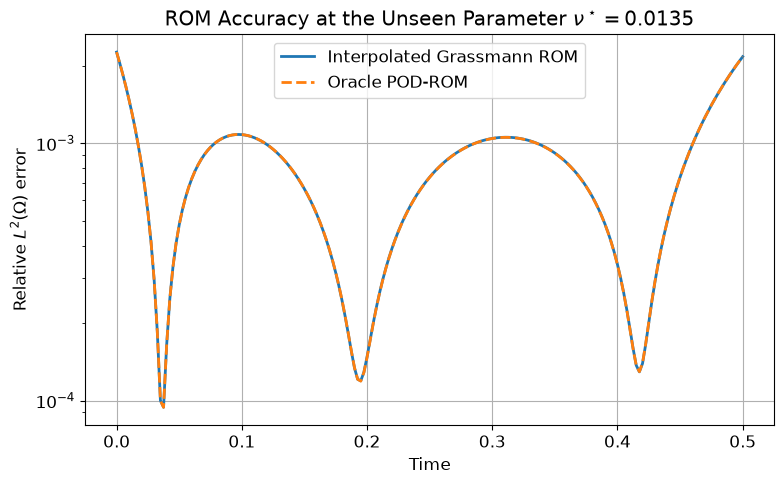

In [73]:
fig, axis = plt.subplots(figsize=(8, 5))

axis.semilogy(
    target_fom_result.time_grid,
    interpolated_rom_errors,
    linewidth=2.0,
    label="Interpolated Grassmann ROM",
)

axis.semilogy(
    target_fom_result.time_grid,
    oracle_rom_errors,
    linestyle="--",
    linewidth=2.0,
    label="Oracle POD-ROM",
)

axis.set_xlabel("Time")
axis.set_ylabel(r"Relative $L^2(\Omega)$ error")
axis.set_title(
    fr"ROM Accuracy at the Unseen Parameter "
    fr"$\nu^\star={PRIMARY_TARGET_DIFFUSIVITY:.4f}$"
)
axis.grid(True)
axis.legend()

fig.tight_layout()
plt.show()

## 10.2 Spatial Comparison at the Final Time

The FOM and interpolated ROM solutions are compared in physical space at $t=T$. The same value range is used for both fields to allow a direct comparison. The third panel displays the pointwise
absolute error.

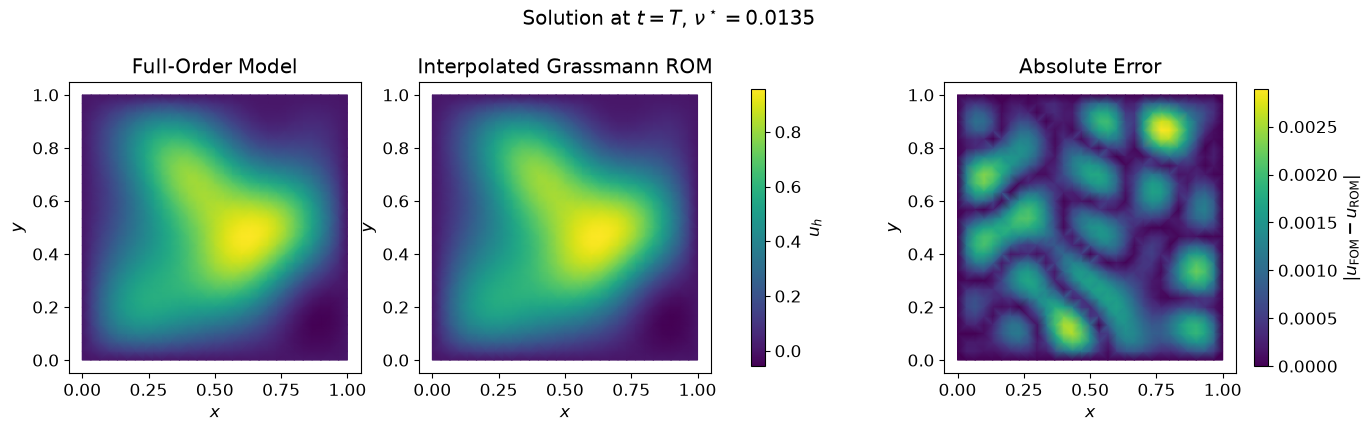

In [74]:
fom_final_state = target_fom_result.final_state
rom_final_state = primary_rom_result.final_state

absolute_final_error = np.abs(
    fom_final_state - rom_final_state
)

field_minimum = min(
    float(np.min(fom_final_state)),
    float(np.min(rom_final_state)),
)

field_maximum = max(
    float(np.max(fom_final_state)),
    float(np.max(rom_final_state)),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
)

fom_plot = axes[0].tripcolor(
    triangulation,
    fom_final_state,
    shading="gouraud",
    vmin=field_minimum,
    vmax=field_maximum,
)

axes[0].set_title("Full-Order Model")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].set_aspect("equal")

rom_plot = axes[1].tripcolor(
    triangulation,
    rom_final_state,
    shading="gouraud",
    vmin=field_minimum,
    vmax=field_maximum,
)

axes[1].set_title("Interpolated Grassmann ROM")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")
axes[1].set_aspect("equal")

error_plot = axes[2].tripcolor(
    triangulation,
    absolute_final_error,
    shading="gouraud",
)

axes[2].set_title("Absolute Error")
axes[2].set_xlabel("$x$")
axes[2].set_ylabel("$y$")
axes[2].set_aspect("equal")

fig.colorbar(
    fom_plot,
    ax=axes[:2],
    shrink=0.8,
    label="$u_h$",
)

fig.colorbar(
    error_plot,
    ax=axes[2],
    shrink=0.8,
    label=r"$|u_{\mathrm{FOM}}-u_{\mathrm{ROM}}|$",
)

fig.suptitle(
    fr"Solution at $t=T$, "
    fr"$\nu^\star={PRIMARY_TARGET_DIFFUSIVITY:.4f}$"
)

plt.show()

In [75]:
print(
    "Validation summary"
)
print(
    "------------------"
)
print(
    f"Target diffusivity          : "
    f"{PRIMARY_TARGET_DIFFUSIVITY:.5f}"
)
print(
    f"Reference diffusivity       : "
    f"{primary_interpolation_result.reference_parameter:.5f}"
)
print(
    f"Reduced dimension           : "
    f"{common_reduced_dimension}"
)
print(
    f"Grassmann subspace distance : "
    f"{interpolated_subspace_distance:.3e}"
)
print(
    f"Mean interpolated ROM error : "
    f"{np.mean(interpolated_rom_errors):.3e}"
)
print(
    f"Mean oracle ROM error       : "
    f"{np.mean(oracle_rom_errors):.3e}"
)
print(
    f"Final interpolated ROM error: "
    f"{interpolated_rom_errors[-1]:.3e}"
)

Validation summary
------------------
Target diffusivity          : 0.01350
Reference diffusivity       : 0.01250
Reduced dimension           : 3
Grassmann subspace distance : 1.856e-05
Mean interpolated ROM error : 7.831e-04
Mean oracle ROM error       : 7.830e-04
Final interpolated ROM error: 2.168e-03


## 10.3 Out-of-Sample Validation Across the Parameter Domain

A single target parameter is not sufficient to assess the interpolation method over the entire parameter domain. The complete set of held-out validation parameters is therefore considered.


For every unseen diffusivity $\nu^\star$:

1. the reduced subspace is interpolated using only the training POD bases;
2. the corresponding POD--Galerkin ROM is solved;
3. a held-out Full-Order Model is computed for validation only;
4. the true POD subspace at $\nu^\star$ is constructed a posteriori;
5. an oracle POD--Galerkin model with the same reduced dimension $r$ is used as a reference.

The interpolated and oracle models are then compared across the validation parameters to separate interpolation error from POD reduction error.

In [76]:
@dataclass(frozen=True)
class ValidationBenchmarkResult:
    """Out-of-sample validation metrics at one parameter value."""

    diffusivity: float
    reference_diffusivity: float
    grassmann_distance: float
    mean_interpolated_rom_error: float
    mean_oracle_rom_error: float
    maximum_interpolated_rom_error: float
    final_interpolated_rom_error: float

In [77]:
validation_fom_results: list[FOMResult] = []

for validation_diffusivity in validation_diffusivities:
    if np.isclose(
        validation_diffusivity,
        PRIMARY_TARGET_DIFFUSIVITY,
        rtol=0.0,
        atol=10.0 * np.finfo(np.float64).eps,
    ):
        fom_result = target_fom_result
    else:
        fom_result = solve_full_order_model(
            diffusivity=float(validation_diffusivity)
        )

    validation_fom_results.append(fom_result)

In [78]:
def evaluate_amsallem_farhat_at_parameter(
    fom_result: FOMResult,
) -> ValidationBenchmarkResult:
    """Evaluate the interpolated and oracle ROMs at one held-out parameter.

    Parameters
    ----------
    fom_result
        Held-out Full-Order Model trajectory used exclusively for validation.

    Returns
    -------
    ValidationBenchmarkResult
        Subspace interpolation error and ROM accuracy metrics.

    Raises
    ------
    RuntimeError
        If the held-out POD rank is smaller than the prescribed common reduced
        dimension.
    """
    diffusivity = fom_result.diffusivity

    interpolation_result = interpolate_amsallem_farhat(
        training_parameters=training_diffusivities,
        euclidean_bases=euclidean_pod_bases,
        target_parameter=diffusivity,
        mass_cholesky_factor=mass_cholesky_factor,
    )

    interpolated_rom = solve_reduced_order_model(
        diffusivity=diffusivity,
        basis=interpolation_result.fem_basis,
        initial_state=full_order_initial_state,
    )

    true_pod_result = compute_mass_weighted_pod(
        fom_result=fom_result,
        mass_cholesky_factor=mass_cholesky_factor,
    )

    if true_pod_result.numerical_rank < common_reduced_dimension:
        raise RuntimeError(
            "The held-out POD rank is smaller than the common "
            f"reduced dimension at nu = {diffusivity:.5f}."
        )

    oracle_fem_basis = true_pod_result.basis[
        :,
        :common_reduced_dimension,
    ]

    oracle_euclidean_basis = (
        map_basis_to_euclidean_coordinates(
            basis=oracle_fem_basis,
            mass_cholesky_factor=mass_cholesky_factor,
        )
    )

    oracle_rom = solve_reduced_order_model(
        diffusivity=diffusivity,
        basis=oracle_fem_basis,
        initial_state=full_order_initial_state,
    )

    interpolated_errors = relative_snapshot_errors(
        reference_snapshots=fom_result.snapshots,
        approximation_snapshots=interpolated_rom.snapshots,
        mass_matrix=mass_matrix_csr,
    )

    oracle_errors = relative_snapshot_errors(
        reference_snapshots=fom_result.snapshots,
        approximation_snapshots=oracle_rom.snapshots,
        mass_matrix=mass_matrix_csr,
    )

    subspace_distance = grassmann_distance(
        first_basis=interpolation_result.euclidean_basis,
        second_basis=oracle_euclidean_basis,
    )

    return ValidationBenchmarkResult(
        diffusivity=diffusivity,
        reference_diffusivity=interpolation_result.reference_parameter,
        grassmann_distance=subspace_distance,
        mean_interpolated_rom_error=float(
            np.mean(interpolated_errors)
        ),
        mean_oracle_rom_error=float(
            np.mean(oracle_errors)
        ),
        maximum_interpolated_rom_error=float(
            np.max(interpolated_errors)
        ),
        final_interpolated_rom_error=float(
            interpolated_errors[-1]
        ),
    )

In [79]:
validation_benchmark = [
    evaluate_amsallem_farhat_at_parameter(fom_result)
    for fom_result in validation_fom_results
]

print(
    "nu*      nu_ref    d_G          "
    "mean ROM     mean oracle   max ROM"
)
print("-" * 73)

for result in validation_benchmark:
    print(
        f"{result.diffusivity:.5f}  "
        f"{result.reference_diffusivity:.5f}  "
        f"{result.grassmann_distance:.3e}  "
        f"{result.mean_interpolated_rom_error:.3e}  "
        f"{result.mean_oracle_rom_error:.3e}  "
        f"{result.maximum_interpolated_rom_error:.3e}"
    )

nu*      nu_ref    d_G          mean ROM     mean oracle   max ROM
-------------------------------------------------------------------------
0.00600  0.00500  9.038e-04  1.240e-04  1.256e-04  4.126e-04
0.00850  0.00750  2.490e-04  2.879e-04  2.866e-04  8.394e-04
0.01100  0.01000  6.287e-05  5.104e-04  5.107e-04  1.482e-03
0.01350  0.01250  1.856e-05  7.831e-04  7.830e-04  2.258e-03
0.01600  0.01500  4.411e-05  1.087e-03  1.087e-03  3.126e-03
0.01850  0.01750  1.701e-04  1.406e-03  1.406e-03  4.046e-03


In [80]:
benchmark_diffusivities = np.array(
    [
        result.diffusivity
        for result in validation_benchmark
    ],
    dtype=np.float64,
)

benchmark_grassmann_distances = np.array(
    [
        result.grassmann_distance
        for result in validation_benchmark
    ],
    dtype=np.float64,
)

benchmark_interpolated_errors = np.array(
    [
        result.mean_interpolated_rom_error
        for result in validation_benchmark
    ],
    dtype=np.float64,
)

benchmark_oracle_errors = np.array(
    [
        result.mean_oracle_rom_error
        for result in validation_benchmark
    ],
    dtype=np.float64,
)

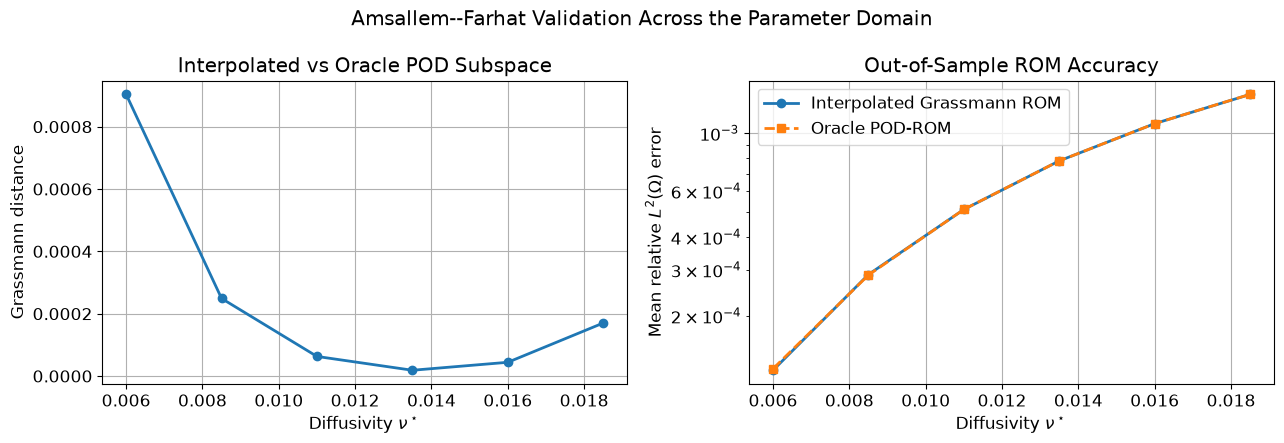

In [81]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

axes[0].plot(
    benchmark_diffusivities,
    benchmark_grassmann_distances,
    marker="o",
    linewidth=2.0,
)

axes[0].set_xlabel(r"Diffusivity $\nu^\star$")
axes[0].set_ylabel("Grassmann distance")
axes[0].set_title("Interpolated vs Oracle POD Subspace")
axes[0].grid(True)

axes[1].semilogy(
    benchmark_diffusivities,
    benchmark_interpolated_errors,
    marker="o",
    linewidth=2.0,
    label="Interpolated Grassmann ROM",
)

axes[1].semilogy(
    benchmark_diffusivities,
    benchmark_oracle_errors,
    marker="s",
    linestyle="--",
    linewidth=2.0,
    label="Oracle POD-ROM",
)

axes[1].set_xlabel(r"Diffusivity $\nu^\star$")
axes[1].set_ylabel(r"Mean relative $L^2(\Omega)$ error")
axes[1].set_title("Out-of-Sample ROM Accuracy")
axes[1].grid(True)
axes[1].legend()

fig.suptitle(
    "Amsallem--Farhat Validation Across the Parameter Domain"
)

fig.tight_layout()
plt.show()

In [82]:
print("Global out-of-sample validation")
print("--------------------------------")

print(
    "Mean Grassmann distance       : "
    f"{np.mean(benchmark_grassmann_distances):.3e}"
)

print(
    "Maximum Grassmann distance    : "
    f"{np.max(benchmark_grassmann_distances):.3e}"
)

print(
    "Mean interpolated ROM error   : "
    f"{np.mean(benchmark_interpolated_errors):.3e}"
)

print(
    "Mean oracle POD-ROM error     : "
    f"{np.mean(benchmark_oracle_errors):.3e}"
)

Global out-of-sample validation
--------------------------------
Mean Grassmann distance       : 2.414e-04
Maximum Grassmann distance    : 9.038e-04
Mean interpolated ROM error   : 6.996e-04
Mean oracle POD-ROM error     : 6.999e-04


# 11. Conclusion

This notebook implemented the Amsallem--Farhat interpolation method on the Grassmann manifold for a parameterized diffusion problem. For each training value of the diffusion coefficient, a mass-weighted POD basis was constructed, transformed to Euclidean coordinates through the Cholesky factorization of the finite element mass matrix, interpolated in the tangent space, and mapped back to the Grassmann manifold. The resulting interpolated basis was then used to build a POD--Galerkin reduced-order model at unseen parameters.

The out-of-sample results show that the interpolated subspaces remain very close to the corresponding POD subspaces computed directly at the target parameters. Over the six validation cases, the mean Grassmann distance is $2.414\times10^{-4}$ and the maximum is $9.038\times10^{-4}$. The mean relative ROM error is $6.996\times10^{-4}$, essentially identical to the $6.999\times10^{-4}$ obtained with the oracle POD--Galerkin models.

These results indicate that, for the diffusion problem and parameter range considered here, the Amsallem--Farhat interpolation accurately reconstructs the parametric reduced subspaces without requiring a Full-Order Model simulation at the target parameter. The method remains local, however, since its applicability depends on the choice of reference point and on the admissible domain of the Grassmann logarithm.
